# MCDI501 — Estadística Computacional para la Toma de Decisiones
## Proyecto Transversal — Fase 1: Análisis Exploratorio e Inferencial

**Título del proyecto:** Análisis Exploratorio e Inferencial del Abandono Académico en Educación Superior

| Campo | Detalle |
|:---|:---|
| **Curso** | MCDI501 — Estadística Computacional para la Toma de Decisiones |
| **Docente** | Jean Paul Maidana González |
| **Grupo** | Grupo 7 |
| **Integrantes** | Juan de Dios Díaz Ríos · Francisco Fariña Molina · Constanza Moreno Giacometto · Yenne Sepúlveda Jerez |
| **Fecha** | Junio 2026 |
| **Dataset** | Predict Students' Dropout and Academic Success — UCI Machine Learning Repository |

---

## Índice

1. [Introducción](#1-introduccion)
2. [Aplicación de estadísticas descriptivas](#2-descriptivas)
   - 2.1 [Descripción del dataset y ficha descriptiva](#2.1-dataset)
   - 2.2 [Configuración del entorno](#2.2-entorno)
   - 2.3 [Carga y limpieza del dataset](#2.3-carga)
   - 2.4 [Reporte de valores faltantes](#2.4-nan)
   - 2.5 [Optimización de tipos de datos](#2.5-tipos)
   - 2.6 [Exploración preliminar](#2.6-exploracion)
   - 2.7 [Medidas descriptivas e interpretación por tipo de variable](#2.7-variables)
3. [Estimación puntual e intervalos de confianza](#3-ic)
4. [Prueba de hipótesis](#4-hipotesis)
5. [Conclusiones](#5-conclusiones)
6. [Referencias](#6-referencias)

---

<a id='1-introduccion'></a>
## 1. Introducción

El abandono académico en la educación superior es un fenómeno complejo que afecta tanto a los estudiantes como a las instituciones educativas. El presente proyecto analiza el **Predict Students' Dropout and Academic Success Dataset** (Realinho et al., 2021), disponible en el UCI Machine Learning Repository, que contiene información sobre **4.424 estudiantes** distribuidos en **37 variables** que describen características demográficas, socioeconómicas, macroeconómicas y de desempeño académico. La variable objetivo (`Target`) clasifica cada estudiante en: **Graduate** (49,9 %), **Dropout** (32,1 %) y **Enrolled** (17,9 %).

> **Decisión técnica — Naturaleza del dataset:** Aunque el dataset contiene todos los registros de una institución específica entre 2008/2009 y 2018/2019, los autores (Realinho et al., 2022) lo construyeron para **generalizar a futuros estudiantes** mediante modelos predictivos. La población de interés es, por tanto, más amplia que los 4.424 registros observados. En consecuencia, el dataset se trata como una **muestra** y las medidas de dispersión se calculan con **pandas (`ddof=1`)**, aplicando la corrección de Bessel. Los intervalos de confianza y la prueba *t* son **estadísticamente válidos** bajo este enfoque.

---

<a id='2-descriptivas'></a>
## 2. Aplicación de estadísticas descriptivas

<a id='2.1-dataset'></a>
### 2.1 Descripción del dataset y ficha descriptiva

| Característica | Detalle |
|:---|:---|
| Fuente | UCI Machine Learning Repository |
| Archivo | `data_predict.csv` |
| Filas | 4.424 estudiantes |
| Columnas | 37 variables (36 predictoras + 1 objetivo) |
| Variable objetivo | `Target` — Graduate / Dropout / Enrolled |
| Separador | Punto y coma (`;`) |
| Naturaleza | **Muestra** (registros 2008/2009–2018/2019; población de interés: futuros estudiantes) |

---

#### Ficha descriptiva del proyecto

| Campo | Descripción |
|:---|:---|
| **Problema** | Identificar los factores estadísticamente asociados al abandono académico en educación superior, como base para el diseño de intervenciones de apoyo estudiantil oportunas |
| **Pregunta central** | ¿Existen diferencias estadísticamente significativas en el perfil académico, socioeconómico y demográfico entre estudiantes que se gradúan y estudiantes que desertan? |
| **Dataset** | Predict Students' Dropout and Academic Success (Realinho et al., 2021) |
| **Institución** | Institución de educación superior pública de Portugal |
| **Población** | 4.424 estudiantes con registro administrativo completo |
| **Variable objetivo** | `Target` con tres categorías: Graduate (49,9 %), Dropout (32,1 %), Enrolled (17,9 %) |
| **Variables predictoras** | 36 variables: 15 nominales · 4 ordinales · 11 discretas · 7 continuas |
| **Período de análisis** | Primer y segundo semestre de la carrera de cada cohorte |

#### Relaciones preliminares identificadas

| Variable | Tipo | Relación esperada con deserción |
|:---|:---|:---|
| Curricular units 1st/2nd sem (approved) | Cuantitativa discreta | Inversa: mayor aprobación → menor riesgo de deserción |
| Curricular units 1st/2nd sem (grade) | Cuantitativa continua | Inversa: mejores notas → menor riesgo de deserción |
| Tuition fees up to date | Nominal binaria | Directa: arancel al día → menor riesgo de deserción |
| Debtor | Nominal binaria | Inversa: deudor → mayor riesgo de deserción |
| Scholarship holder | Nominal binaria | Directa: becado → menor riesgo de deserción |
| Age at enrollment | Cuantitativa discreta | Directa: mayor edad → mayor riesgo de deserción |
| Admission grade | Cuantitativa continua | Inversa: mayor nota de ingreso → menor riesgo de deserción |
| Previous qualification (grade) | Cuantitativa continua | Inversa: mayor calificación previa → menor riesgo |
| Gender | Nominal binaria | A explorar: posibles diferencias por género |
| Daytime/evening attendance | Nominal binaria | A explorar: jornada vespertina podría implicar mayor riesgo |

> **Nota metodológica:** estas relaciones son hipótesis preliminares basadas en el marco teórico de la deserción estudiantil. Su validación estadística se realiza en las secciones 3 y 4 del presente informe.

---

### Clasificación de variables

| (a) Cualitativa Nominal | (b) Cualitativa Ordinal | (c) Cuantitativa Discreta | (d) Cuantitativa Continua |
|:---|:---|:---|:---|
| Marital status | Previous qualification | Age at enrollment | Previous qualification (grade) |
| Application mode | Mother's qualification | Curricular units 1st sem (credited) | Admission grade |
| Course | Father's qualification | Curricular units 1st sem (enrolled) | Curricular units 1st sem (grade) |
| Daytime/evening attendance | Application order | Curricular units 1st sem (evaluations) | Curricular units 2nd sem (grade) |
| Nationality | | Curricular units 1st sem (approved) | Unemployment rate |
| Mother's occupation | | Curricular units 1st sem (without evaluations) | Inflation rate |
| Father's occupation | | Curricular units 2nd sem (credited) | GDP |
| Displaced | | Curricular units 2nd sem (enrolled) | |
| Educational special needs | | Curricular units 2nd sem (evaluations) | |
| Debtor | | Curricular units 2nd sem (approved) | |
| Tuition fees up to date | | Curricular units 2nd sem (without evaluations) | |
| Gender | | | |
| Scholarship holder | | | |
| International | | | |
| Target ★ | | | |
| **15** | **4** | **11** | **7** |

> **Medidas válidas por tipo** (F1-2a):
> (a) Nominal → moda, proporción  ·  (b) Ordinal → moda, mediana, rango
> (c) Discreta → media, mediana, moda, σ, σ², IQR, asimetría, curtosis
> (d) Continua → ídem discreta + percentiles

---

<a id='2.2-entorno'></a>
### 2.2 Configuración del entorno

---

In [1]:
# ============================================================
# REGISTRO DEL ENTORNO DE EJECUCIÓN
# ============================================================
import sys, platform

print("=" * 55)
print("ENTORNO DE EJECUCIÓN — Proyecto Grupo 7 MCDI501")
print("=" * 55)
print(f"Sistema operativo : {platform.system()} {platform.release()}")
print(f"Python            : {sys.version}")
print("=" * 55)

ENTORNO DE EJECUCIÓN — Proyecto Grupo 7 MCDI501
Sistema operativo : Windows 11
Python            : 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [2]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN GLOBAL
# ─────────────────────────────────────────────────────────────
# DECISIÓN numpy vs pandas (F1-2b):
#   pandas (ddof=1) → estadística MUESTRAL  ← este proyecto
#   numpy  (ddof=0) → estadística poblacional (no aplica aquí)
# ─────────────────────────────────────────────────────────────
# Seaborn: "opción recomendada para análisis exploratorio
#  y reportes estadísticos" (F1-3)
# ============================================================
import sys, os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats          # IC + prueba t


# ── Configuración global de Seaborn (F1-3: whitegrid + notebook)
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
sns.set_context("notebook")
plt.rcParams['figure.dpi'] = 100
pd.options.display.float_format = '{:.4f}'.format

print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"seaborn : {sns.__version__}")
print("✓ Entorno listo.")

pandas  : 2.3.3
numpy   : 2.3.5
seaborn : 0.13.2
✓ Entorno listo.


<a id='2.3-carga'></a>
### 2.3 Carga y limpieza del dataset

---

In [3]:
# ============================================================
# CARGA DEL DATASET
# ============================================================
from functions import *

RUTA_data = "data/raw/data_predict.csv"
df_data = cargar_dataset(RUTA_data)

# Normalizar nombres de columna (elimina tabuladores y espacios)
df_data.columns = (
    df_data.columns
    .str.replace("\t", "", regex=False)
    .str.strip()
)

print(f"  Filas    : {df_data.shape[0]:,}")
print(f"  Columnas : {df_data.shape[1]}")
print(f"  Columnas : {df_data.columns.tolist()}")

✓ Dataset cargado correctamente desde: data/raw/data_predict.csv
  4,424 filas × 37 columnas
  Filas    : 4,424
  Columnas : 37
  Columnas : ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular un

<a id='2.4-nan'></a>
### 2.4 Reporte de valores faltantes (NaN)

---

In [4]:
# ============================================================
# REPORTE DE VALORES FALTANTES — obligatorio antes de analizar
# ============================================================
nan_abs = df_data.isnull().sum()
nan_pct = (nan_abs / len(df_data) * 100).round(2)

reporte_nan = pd.DataFrame({
    'N NaN'  : nan_abs,
    '% NaN'  : nan_pct,
    'Tipo'   : df_data.dtypes,
}).sort_values('N NaN', ascending=False)

print(f"Columnas con NaN : {(nan_abs > 0).sum()}")
print(f"Total NaN        : {nan_abs.sum():,}\n")

if nan_abs.sum() == 0:
    print("✓ No se detectaron valores faltantes.")
else:
    display(reporte_nan[reporte_nan['N NaN'] > 0])

Columnas con NaN : 0
Total NaN        : 0

✓ No se detectaron valores faltantes.


<a id='2.5-tipos'></a>
### 2.5 Optimización de tipos de datos

Se aplican las conversiones recomendadas en F1-2a:
- **Nominales** → `category` (ahorro de hasta 90 % de memoria en columnas repetidas)
- **Ordinales/Discretas** → `int16` (rango −32 768 a 32 767, suficiente para todos los recuentos)
- **Continuas** → `float32` (7 dígitos de precisión, suficiente para escalas 0–200)

---

In [5]:
# ============================================================
# OPTIMIZACIÓN DE TIPOS DE DATOS (F1-2a)
# ============================================================

vars_cat = [                          # (a) Nominales → category
    'Marital status', 'Application mode', 'Course',
    'Daytime/evening attendance', 'Nacionality',
    "Mother's occupation", "Father's occupation",
    'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder',
    'International', 'Target',
]
vars_int16 = [                        # (b) Ordinales + (c) Discretas → int16
    'Previous qualification', "Mother's qualification",
    "Father's qualification", 'Application order',
    'Age at enrollment',
    'Curricular units 1st sem (credited)',  'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',  'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (without evaluations)',
]
vars_float32 = [                      # (d) Continuas → float32
    'Previous qualification (grade)', 'Admission grade',
    'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'Inflation rate', 'GDP',
]

mem_antes = df_data.memory_usage(deep=True).sum() / 1024**2

for col in vars_cat:
    if col in df_data.columns:
        df_data[col] = df_data[col].astype('category')
for col in vars_int16:
    if col in df_data.columns and df_data[col].isnull().sum() == 0:
        df_data[col] = df_data[col].astype('int16')
for col in vars_float32:
    if col in df_data.columns:
        df_data[col] = df_data[col].astype('float32')

mem_despues = df_data.memory_usage(deep=True).sum() / 1024**2
print(f"Memoria antes    : {mem_antes:.2f} MB")
print(f"Memoria después  : {mem_despues:.2f} MB")
print(f"Reducción        : {(1 - mem_despues/mem_antes)*100:.1f} %")
print(f"\nTipos resultantes:\n{df_data.dtypes.to_string()}")

Memoria antes    : 1.45 MB
Memoria después  : 0.31 MB
Reducción        : 78.4 %

Tipos resultantes:
Marital status                                    category
Application mode                                  category
Application order                                    int16
Course                                            category
Daytime/evening attendance                        category
Previous qualification                               int16
Previous qualification (grade)                     float32
Nacionality                                       category
Mother's qualification                               int16
Father's qualification                               int16
Mother's occupation                               category
Father's occupation                               category
Admission grade                                    float32
Displaced                                         category
Educational special needs                         category
Debtor         

<a id='2.6-exploracion'></a>
### 2.6 Exploración preliminar

---

In [6]:
print("Primeras filas del dataset:")
mostrar_primeras_filas(df_data, 10)

Primeras filas del dataset:

Primeras 10 filas:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0000,1,19,12,...,0,0,0,0,0.0000,0,10.8000,1.4000,1.7400,Dropout
1,1,15,1,9254,1,1,160.0000,1,1,3,...,0,6,6,6,13.6667,0,13.9000,-0.3000,0.7900,Graduate
2,1,1,5,9070,1,1,122.0000,1,37,37,...,0,6,0,0,0.0000,0,10.8000,1.4000,1.7400,Dropout
3,1,17,2,9773,1,1,122.0000,1,38,37,...,0,6,10,5,12.4000,0,9.4000,-0.8000,-3.1200,Graduate
4,2,39,1,8014,0,1,100.0000,1,37,38,...,0,6,6,6,13.0000,0,13.9000,-0.3000,0.7900,Graduate
5,2,39,1,9991,0,19,133.1000,1,37,37,...,0,5,17,5,11.5000,5,16.2000,0.3000,-0.9200,Graduate
6,1,1,1,9500,1,1,142.0000,1,19,38,...,0,8,8,8,14.3450,0,15.5000,2.8000,-4.0600,Graduate
7,1,18,4,9254,1,1,119.0000,1,37,37,...,0,5,5,0,0.0000,0,15.5000,2.8000,-4.0600,Dropout
8,1,1,3,9238,1,1,137.0000,62,1,1,...,0,6,7,6,14.1429,0,16.2000,0.3000,-0.9200,Graduate
9,1,1,1,9238,1,1,138.0000,1,1,19,...,0,6,14,2,13.5000,0,8.9000,1.4000,3.5100,Dropout


In [7]:
resumen_dataset(df_data, nombre="Dataset data_predict")


  RESUMEN — Dataset data_predict
  Filas             : 4,424
  Columnas          : 37
  Duplicados        : 0
  Valores NaN total : 0

  Tipos de datos:
    int16           : 15 columnas
    category        : 8 columnas
    float32         : 7 columnas
    category        : 1 columnas
    category        : 1 columnas
    category        : 1 columnas
    category        : 1 columnas
    category        : 1 columnas
    category        : 1 columnas
    category        : 1 columnas


<a id='2.7-variables'></a>
### 2.7 Medidas descriptivas por tipo de variable

**Criterio estadístico** (F1-2b): el dataset se trata como **muestra** — los modelos predictivos se generalizan a futuros estudiantes (Realinho et al., 2022).

| Estadístico | Fórmula | Librería | Cuándo |
|:---|:---|:---|:---|
| s (desv. estándar) | Divide por **n−1** | **`pandas` `ddof=1`** | **Muestra ← este análisis** |
| σ (desv. estándar) | Divide por **N** | `numpy` `ddof=0` | Solo si fuera población (no aplica) |
| Asimetría g₁ | Corrección muestral | **`pandas .skew()`** | **Muestra ← este análisis** |
| Curtosis g₂ | Corrección muestral | **`pandas .kurt()`** | **Muestra ← este análisis** |

Los gráficos usan **Seaborn** en todos los tipos de variable (F1-3):
`sns.histplot` · `sns.countplot` · `sns.barplot`

---

#### (d) Variables cuantitativas continuas

Medidas válidas: tendencia central + dispersión (σ, σ²) + forma (g₁, g₂).
Asimetría y curtosis son **exclusivas de variables cuantitativas** (F1-2a, F1-2b).

---

In [8]:
# ============================================================
# MEDIDAS DESCRIPTIVAS — VARIABLES CUANTITATIVAS CONTINUAS (d)
# pandas ddof=1 → MUESTRA (F1-2b)
# pandas .skew() y .kurt() → corrección muestral por defecto
# ============================================================

vars_continuas = [
    'Previous qualification (grade)', 'Admission grade',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

resumen_continuas = pd.DataFrame({
    'NaN':     df_data[vars_continuas].isnull().sum(),
    'x̄':      df_data[vars_continuas].mean(),
    'Mediana': df_data[vars_continuas].median(),
    'Moda':    df_data[vars_continuas].mode().iloc[0],
    's':       df_data[vars_continuas].std(ddof=1),        # pandas — MUESTRA
    's²':      df_data[vars_continuas].var(ddof=1),        # pandas — MUESTRA
    'Mín':     df_data[vars_continuas].min(),
    'Máx':     df_data[vars_continuas].max(),
    'Rango':   df_data[vars_continuas].max() - df_data[vars_continuas].min(),
    'Q1':      df_data[vars_continuas].quantile(0.25),
    'Q3':      df_data[vars_continuas].quantile(0.75),
    'IQR':     df_data[vars_continuas].quantile(0.75) - df_data[vars_continuas].quantile(0.25),
    'g₁':      df_data[vars_continuas].skew(),             # pandas — corrección muestral
    'g₂':      df_data[vars_continuas].kurt(),             # pandas — corrección muestral
}).round(4)

print("=== Medidas descriptivas — Continuas (d) | pandas ddof=1 (MUESTRA) ===")
resumen_continuas

=== Medidas descriptivas — Continuas (d) | pandas ddof=1 (MUESTRA) ===


,NaN,x̄,Mediana,Moda,s,s²,Mín,Máx,Rango,Q1,Q3,IQR,g₁,g₂
Previous qualification (grade),0,132.6133,133.1000,133.1000,13.1884,173.9328,95.0000,190.0000,95.0000,125.0000,140.0000,15.0000,0.3129,0.9683
Admission grade,0,126.9781,126.1000,130.0000,14.4820,209.7279,95.0000,190.0000,95.0000,117.9000,134.8000,16.9000,0.5306,0.6627
Curricular units 1st sem (grade),0,10.6408,12.2857,0.0000,4.8436,23.4609,0.0000,18.8750,18.8750,11.0000,13.4000,2.4000,-1.5681,0.9085
Curricular units 2nd sem (grade),0,10.2302,12.2000,0.0000,5.2108,27.1524,0.0000,18.5714,18.5714,10.7500,13.3333,2.5833,-1.3136,0.0666
Unemployment rate,0,11.5661,11.1000,7.6000,2.6638,7.0960,7.6000,16.2000,8.6000,9.4000,13.9000,4.5000,0.2121,-0.9955
Inflation rate,0,1.2280,1.4000,1.4000,1.3827,1.9119,-0.8000,3.7000,4.5000,0.3000,2.6000,2.3000,0.2524,-1.0390
GDP,0,0.0020,0.3200,0.3200,2.2699,5.1527,-4.0600,3.5100,7.5700,-1.7000,1.7900,3.4900,-0.3941,-1.0017


C:\Users\juan.diaz\AppData\Local\Temp\ipykernel_31088\1069823837.py:50: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\juan.diaz\AppData\Local\Temp\ipykernel_31088\1069823837.py:50: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\juan.diaz\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\juan.diaz\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


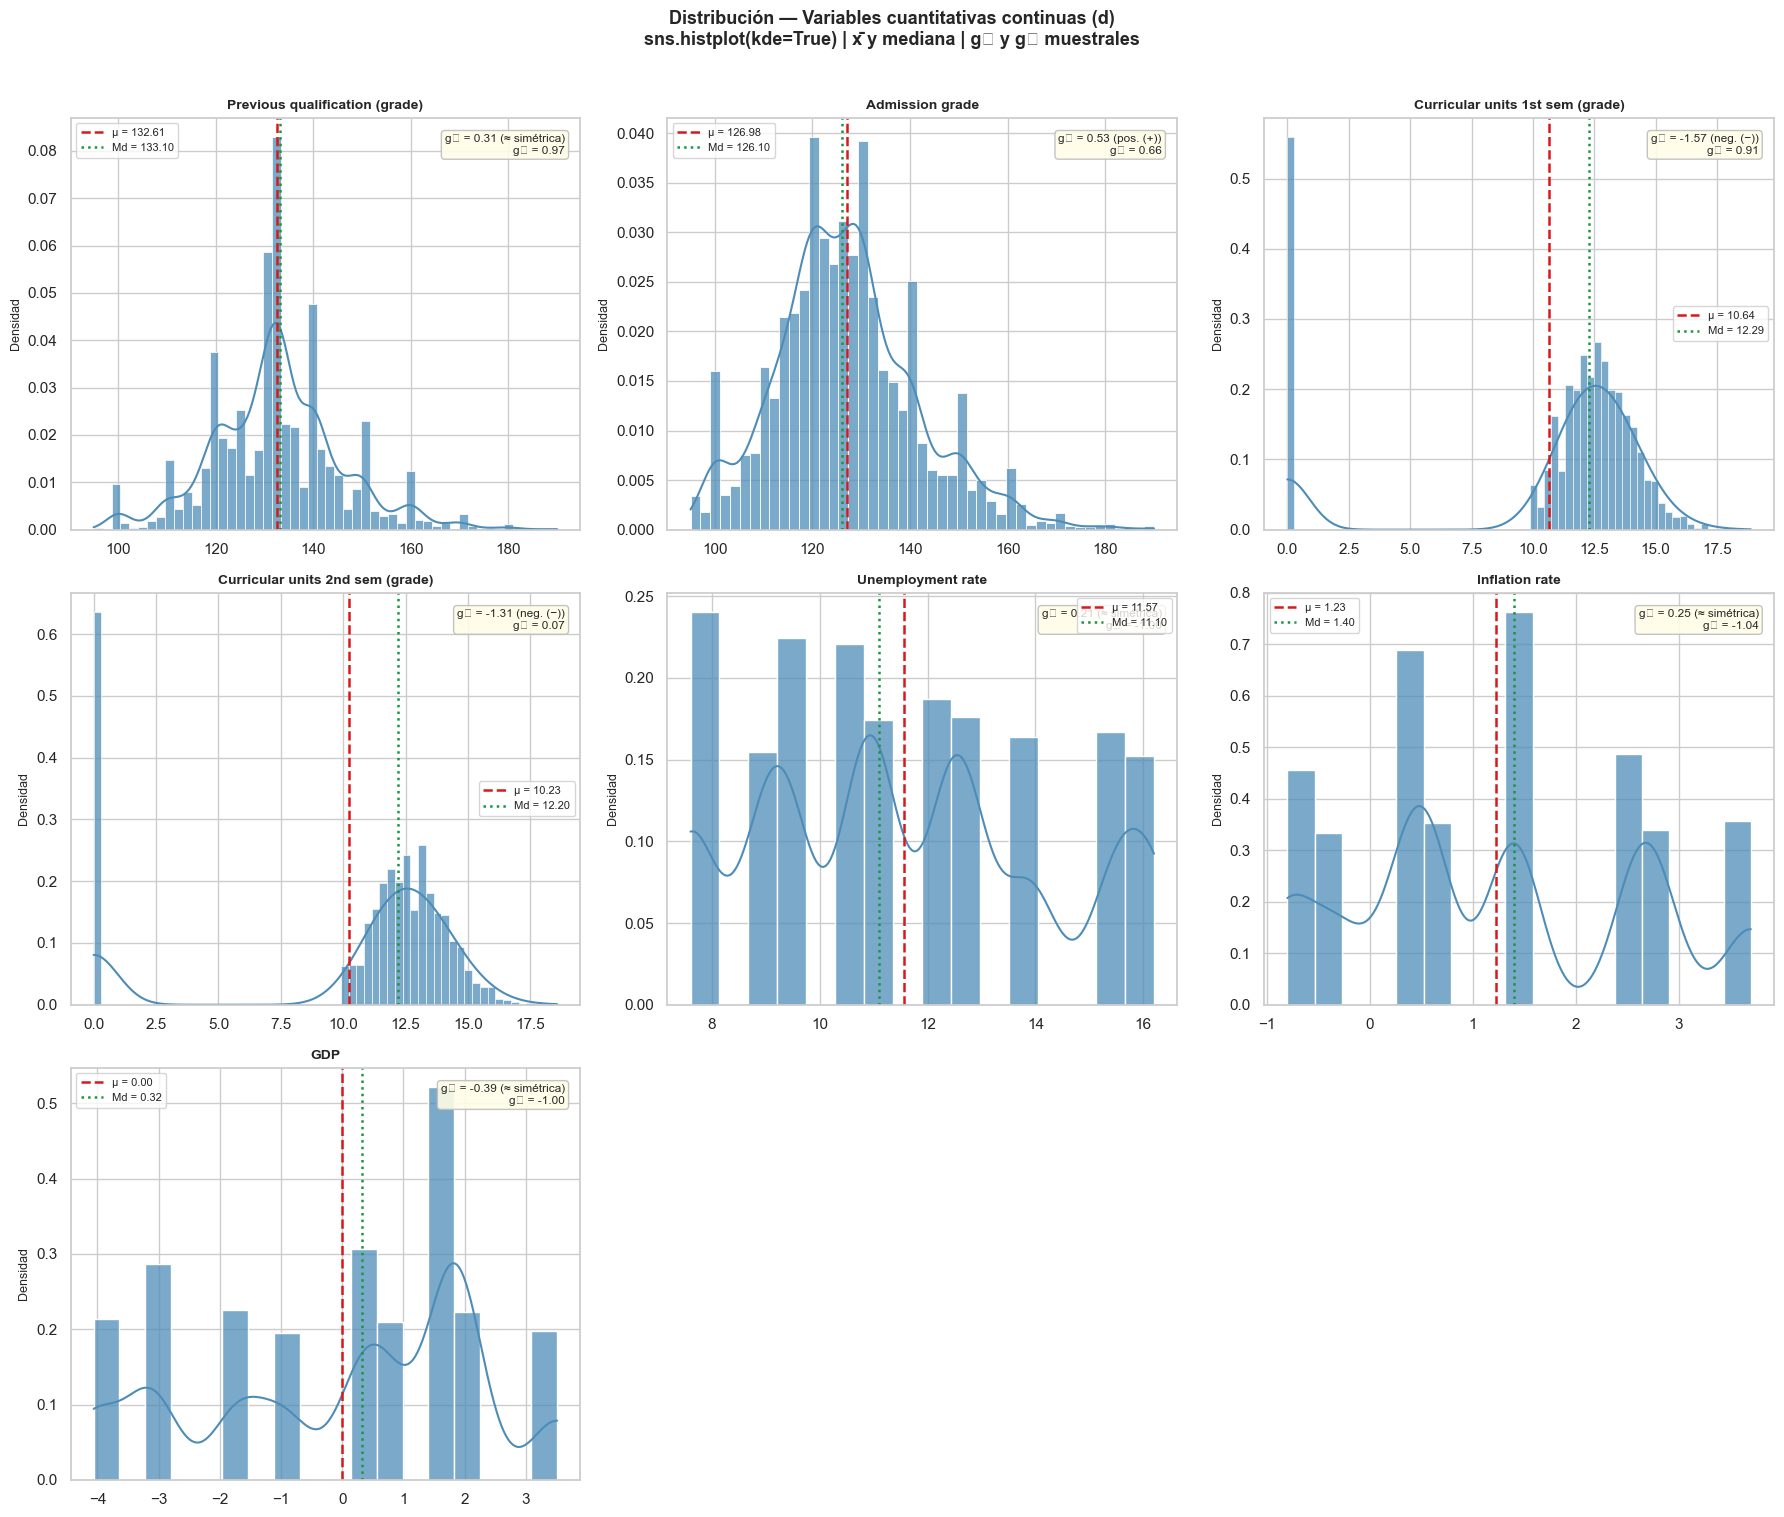

In [9]:
# ============================================================
# VISUALIZACIÓN — CONTINUAS (d)
# sns.histplot(kde=True) — F1-3: gráfico recomendado para 1 variable continua
# ============================================================

COLOR_HIST  = "#4E8CB8"
COLOR_MEDIA = "#D7191C"
COLOR_MED   = "#1A9641"

n_cols = 3
n_rows = math.ceil(len(vars_continuas) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(vars_continuas):
    ax    = axes[i]
    datos = df_data[col].dropna().astype(float)

    sns.histplot(data=df_data, x=col, kde=True, stat="density",
                 color=COLOR_HIST, edgecolor="white", alpha=0.75, ax=ax)

    mu  = float(datos.mean())
    med = float(datos.median())
    ax.axvline(mu,  color=COLOR_MEDIA, linestyle="--", lw=1.8,
               label=f"μ = {mu:.2f}")
    ax.axvline(med, color=COLOR_MED,   linestyle=":",  lw=1.8,
               label=f"Md = {med:.2f}")

    g1 = float(datos.skew())          # pandas — corrección muestral
    g2 = float(datos.kurt())          # pandas — corrección muestral
    asim = "≈ simétrica" if abs(g1) < 0.5 else ("pos. (+)" if g1 > 0 else "neg. (−)")
    ax.annotate(
        f"g₁ = {g1:.2f} ({asim})\ng₂ = {g2:.2f}",
        xy=(0.97, 0.96), xycoords="axes fraction",
        ha="right", va="top", fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFFDE7", ec="#BDBDBD", alpha=0.9)
    )

    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("Densidad", fontsize=9)
    ax.legend(fontsize=8)

for j in range(len(vars_continuas), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribución — Variables cuantitativas continuas (d)\n"
             "sns.histplot(kde=True) | x̄ y mediana | g₁ y g₂ muestrales",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

#### Interpretación — Variables cuantitativas continuas

El análisis de las 7 variables continuas revela los siguientes patrones:

- **`Previous qualification (grade)` y `Admission grade`**: ambas presentan distribuciones aproximadamente simétricas (|g₁| < 0,5), con medias alrededor de 130/200 y 127/200 respectivamente. Los IC estrechos confirman alta precisión en la estimación. Estos valores sugieren que la institución concentra estudiantes con desempeño de ingreso medio-alto, sin extremos pronunciados.

- **`Curricular units 1st/2nd sem (grade)`**: presentan **asimetría negativa** (cola hacia valores bajos), indicando que la mayoría de los estudiantes obtiene notas superiores a la media, pero existe una minoría con rendimiento notablemente bajo. Esta distribución es clave para identificar grupos en riesgo de deserción, ya que los valores en la cola izquierda corresponden predominantemente a estudiantes que desertaron.

- **`Unemployment rate` e `Inflation rate`**: presentan **asimetría positiva** con mayor variabilidad (CV elevado), reflejando los distintos contextos económicos de las cohortes de ingreso analizadas. El GDP muestra valores tanto positivos como negativos, consistente con períodos de recesión y crecimiento en el horizonte temporal del estudio.

> **Relación con el problema:** las variables de rendimiento académico continuo (notas de 1.° y 2.° semestre) son candidatas fuertes como predictores de deserción, mientras que las variables macroeconómicas actúan como variables de contexto.

---

#### (c) Variables cuantitativas discretas

Mismas medidas que continuas. Se incluyen asimetría y curtosis (válidas para toda variable cuantitativa). s y s² calculadas con pandas `ddof=1` (muestra, corrección de Bessel).

---

In [10]:
# ============================================================
# MEDIDAS DESCRIPTIVAS — VARIABLES CUANTITATIVAS DISCRETAS (c)
# pandas ddof=1 → MUESTRA (F1-2b)
# ============================================================

vars_discreta = [
    'Age at enrollment',
    'Curricular units 1st sem (credited)',  'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',  'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (without evaluations)',
]

resumen_discretas = pd.DataFrame({
    'NaN':     df_data[vars_discreta].isnull().sum(),
    'x̄':      df_data[vars_discreta].mean(),
    'Mediana': df_data[vars_discreta].median(),
    'Moda':    df_data[vars_discreta].mode().iloc[0],
    's':       df_data[vars_discreta].std(ddof=1),         # pandas — MUESTRA
    's²':      df_data[vars_discreta].var(ddof=1),         # pandas — MUESTRA
    'Mín':     df_data[vars_discreta].min(),
    'Máx':     df_data[vars_discreta].max(),
    'Rango':   df_data[vars_discreta].max() - df_data[vars_discreta].min(),
    'IQR':     df_data[vars_discreta].quantile(0.75) - df_data[vars_discreta].quantile(0.25),
    'g₁':      df_data[vars_discreta].skew(),              # pandas — corrección muestral
    'g₂':      df_data[vars_discreta].kurt(),              # pandas — corrección muestral
}).round(4)

print("=== Medidas descriptivas — Discretas (c) | pandas ddof=1 (MUESTRA) ===")
resumen_discretas

=== Medidas descriptivas — Discretas (c) | pandas ddof=1 (MUESTRA) ===


,NaN,x̄,Mediana,Moda,s,s²,Mín,Máx,Rango,IQR,g₁,g₂
Age at enrollment,0,23.2651,20.0000,18,7.5878,57.5749,17,70,53,6.0000,2.0550,4.1269
Curricular units 1st sem (credited),0,0.7100,0.0000,0,2.3605,5.5720,0,20,20,0.0000,4.1690,19.2057
Curricular units 1st sem (enrolled),0,6.2706,6.0000,6,2.4802,6.1513,0,26,26,2.0000,1.6190,8.9379
Curricular units 1st sem (evaluations),0,8.2991,8.0000,8,4.1791,17.4649,0,45,45,4.0000,0.9766,5.4630
Curricular units 1st sem (approved),0,4.7066,5.0000,6,3.0942,9.5743,0,26,26,3.0000,0.7663,3.0967
Curricular units 1st sem (without evaluations),0,0.1377,0.0000,0,0.6909,0.4773,0,12,12,0.0000,8.2074,89.8632
Curricular units 2nd sem (credited),0,0.5418,0.0000,0,1.9185,3.6808,0,19,19,0.0000,4.6348,24.4273
Curricular units 2nd sem (enrolled),0,6.2321,6.0000,6,2.1960,4.8222,0,23,23,2.0000,0.7881,7.1347
Curricular units 2nd sem (evaluations),0,8.0633,8.0000,8,3.9480,15.5863,0,33,33,4.0000,0.3365,2.0683
Curricular units 2nd sem (approved),0,4.4358,5.0000,6,3.0148,9.0888,0,20,20,4.0000,0.3063,0.8450


Violinplot (7 vars): ['Age at enrollment', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)']
Barplot media (4 vars): ['Curricular units 1st sem (credited)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (without evaluations)']


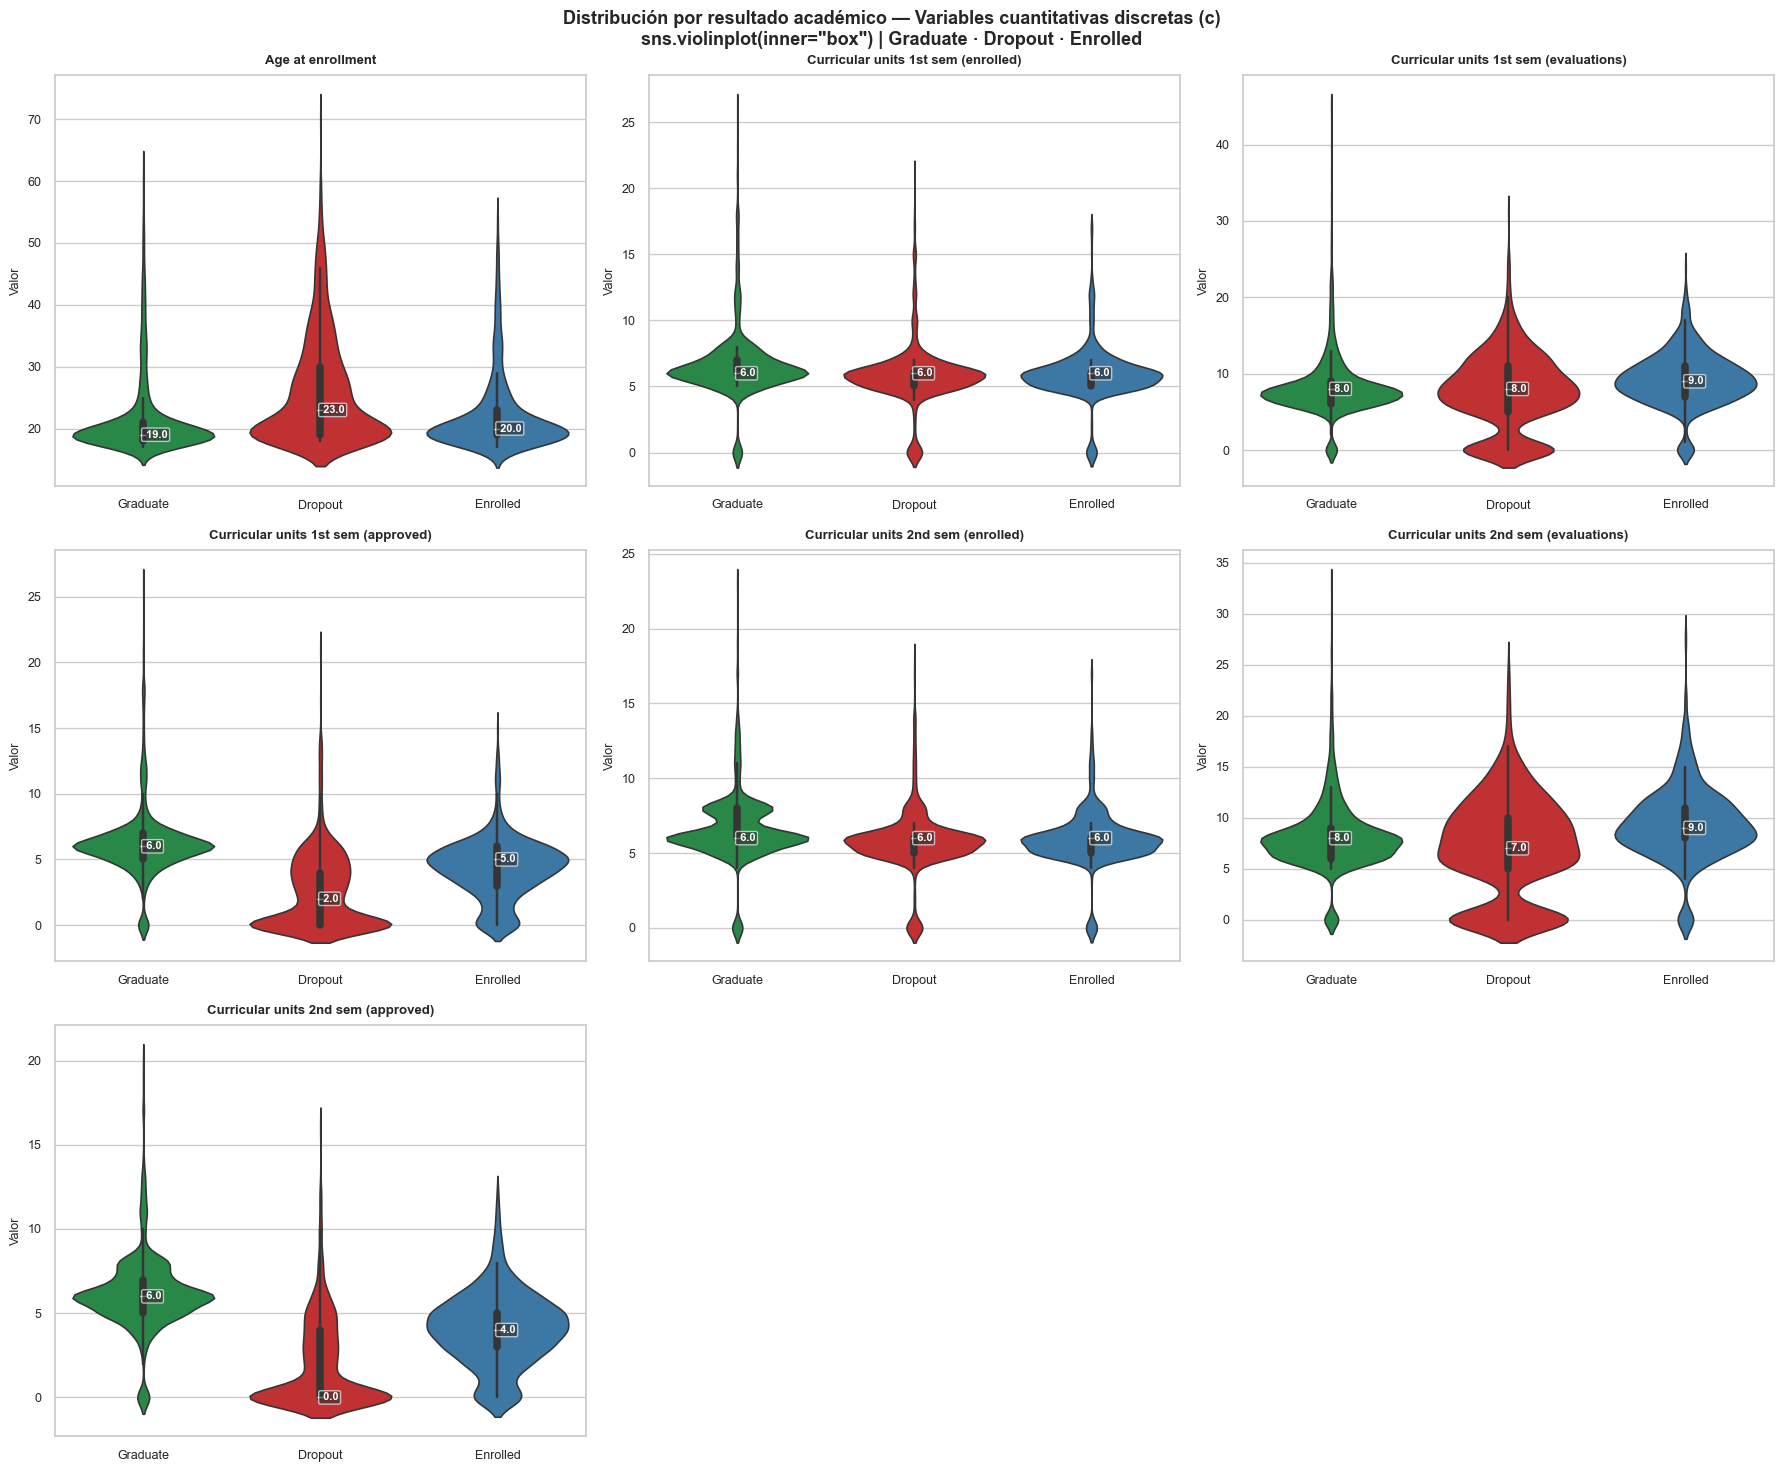

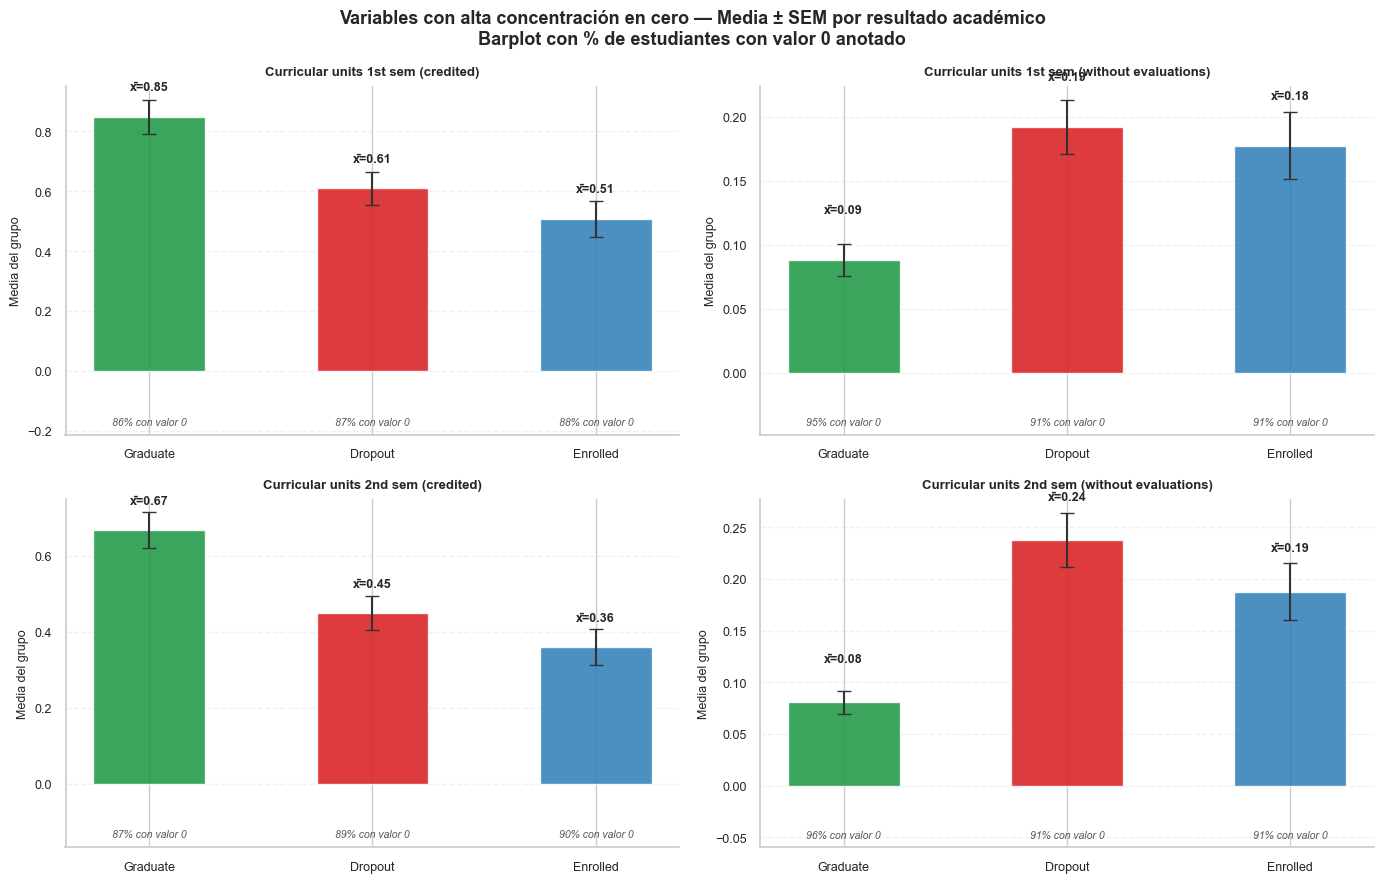

In [11]:
# ============================================================
# VISUALIZACIÓN — DISCRETAS (c)
# Clasificación automática por distribución:
#   Variables con > 40% de ceros → barplot de media ± SEM por Target
#   (el boxplot colapsa cuando casi todo el rango está en 0)
#   Resto → violinplot(inner='box') por Target
# ============================================================
import numpy as np

ORDEN_TARGET = ['Graduate', 'Dropout', 'Enrolled']
PAL_TARGET   = {'Graduate': '#1A9641', 'Dropout': '#D7191C', 'Enrolled': '#2C7BB6'}

# Clasificar automáticamente según concentración de ceros
vars_violin = [c for c in vars_discreta
               if (df_data[c] == 0).mean() <= 0.40]
vars_zero   = [c for c in vars_discreta
               if (df_data[c] == 0).mean() >  0.40]

print(f"Violinplot ({len(vars_violin)} vars): {vars_violin}")
print(f"Barplot media ({len(vars_zero)} vars): {vars_zero}")

# ── Panel A: Violin con boxplot interior ─────────────────────
if vars_violin:
    n_cols = 3
    n_rows = math.ceil(len(vars_violin) / n_cols)
    fig_a, axes_a = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes_a = np.array(axes_a).flatten()

    for i, col in enumerate(vars_violin):
        ax = axes_a[i]
        datos_col = df_data[['Target', col]].copy()
        datos_col[col] = datos_col[col].astype(float)

        sns.violinplot(
            data=datos_col, x='Target', y=col,
            order=ORDEN_TARGET,
            hue='Target', hue_order=ORDEN_TARGET,
            palette=PAL_TARGET,
            inner='box',     # miniboxplot dentro del violín
            legend=False,
            linewidth=1.2,
            ax=ax
        )

        # Mediana anotada
        for j, grupo in enumerate(ORDEN_TARGET):
            med = datos_col[datos_col['Target'] == grupo][col].median()
            ax.text(j, med, f' {med:.1f}',
                    va='center', ha='left', fontsize=8, fontweight='bold',
                    color='white',
                    bbox=dict(boxstyle='round,pad=0.15', fc='#333333', alpha=0.65))

        ax.set_title(col, fontsize=9.5, fontweight='bold', pad=8)
        ax.set_xlabel(''); ax.set_ylabel('Valor', fontsize=9)
        ax.tick_params(labelsize=9)

    for j in range(len(vars_violin), len(axes_a)):
        fig_a.delaxes(axes_a[j])

    fig_a.suptitle(
        'Distribución por resultado académico — Variables cuantitativas discretas (c)\n'
        'sns.violinplot(inner="box") | Graduate · Dropout · Enrolled',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout(); plt.show()

# ── Panel B: Barplot media ± SEM para vars con muchos ceros ──
if vars_zero:
    n_cols = 2
    n_rows = math.ceil(len(vars_zero) / n_cols)
    fig_b, axes_b = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows))
    axes_b = np.array(axes_b).flatten()

    for i, col in enumerate(vars_zero):
        ax = axes_b[i]

        medias = []
        for grupo in ORDEN_TARGET:
            sub = df_data[df_data['Target'] == grupo][col].dropna().astype(float)
            medias.append({'Grupo': grupo,
                           'Media': sub.mean(),
                           'SEM':   sub.sem(),
                           'pct0':  (sub == 0).mean() * 100})
        df_m = pd.DataFrame(medias)

        bars = ax.bar(
            df_m['Grupo'], df_m['Media'],
            color=[PAL_TARGET[g] for g in df_m['Grupo']],
            edgecolor='white', alpha=0.85, width=0.5
        )
        ax.errorbar(
            df_m['Grupo'], df_m['Media'],
            yerr=df_m['SEM'],
            fmt='none', color='#333333', capsize=5, linewidth=1.5
        )

        # Valor de la media sobre cada barra
        for bar, (_, row) in zip(bars, df_m.iterrows()):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + df_m['SEM'].max() * 1.3,
                    f'x̄={row["Media"]:.2f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

        # Porcentaje con valor 0 debajo del eje
        ymin = -df_m['Media'].max() * 0.18
        for j, (_, row) in enumerate(df_m.iterrows()):
            ax.text(j, ymin,
                    f'{row["pct0"]:.0f}% con valor 0',
                    ha='center', va='top', fontsize=7.5,
                    color='#555555', style='italic')

        ax.set_title(col, fontsize=9.5, fontweight='bold', pad=8)
        ax.set_xlabel(''); ax.set_ylabel('Media del grupo', fontsize=9)
        ax.set_ylim(bottom=ymin * 1.4)
        ax.tick_params(labelsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for j in range(len(vars_zero), len(axes_b)):
        fig_b.delaxes(axes_b[j])

    fig_b.suptitle(
        'Variables con alta concentración en cero — Media ± SEM por resultado académico\n'
        'Barplot con % de estudiantes con valor 0 anotado',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout(); plt.show()


#### Interpretación — Variables cuantitativas discretas

Los boxplots por grupo `Target` permiten comparar visualmente la distribución de cada variable según el resultado académico:

- **`Curricular units approved` (1.° y 2.° semestre)**: esta es la diferencia más pronunciada entre grupos. Los estudiantes **Graduate** concentran sus cajas en valores altos (mediana entre 5 y 6 unidades aprobadas), mientras que los **Dropout** presentan medianas cercanas a cero o muy bajas. Esta variable constituye el indicador más discriminante del resultado académico final.

- **`Curricular units enrolled` y `evaluations`**: también muestran diferencias entre grupos, aunque menos extremas que las unidades aprobadas. Los graduados tienden a inscribir y rendir más evaluaciones que los desertores.

- **`Age at enrollment`**: los **Dropout** presentan una mediana de edad de ingreso levemente superior y mayor dispersión (IQR más amplio) que los **Graduate**, lo que es consistente con la literatura sobre mayor riesgo de deserción en estudiantes no tradicionales o que retoman estudios.

- **`Curricular units credited` y `without evaluations`**: ambos grupos presentan distribuciones fuertemente concentradas en cero (moda = 0), con alta asimetría positiva. Los valores extremos corresponden a casos de convalidación o situaciones académicas especiales.

> **Relación con el problema:** el desempeño del **primer semestre** (unidades aprobadas y evaluaciones rendidas) emerge como el factor más diferenciador entre grupos, sugiriendo que la detección temprana de riesgo debe centrarse en este período.

---

#### (b) Variables cualitativas ordinales

Medidas válidas: **moda, mediana y rango** (F1-2a). No se calculan media, σ, asimetría ni curtosis porque las distancias entre categorías no son iguales.

---

In [12]:
# ============================================================
# MEDIDAS DESCRIPTIVAS — ORDINALES (b)
# Válidas: moda, mediana, rango | NO: media, σ, asimetría (F1-2a)
# ============================================================

vars_ordinal = [
    'Previous qualification', "Mother's qualification",
    "Father's qualification", 'Application order',
]

resumen_ordinales = pd.DataFrame({
    'NaN':     df_data[vars_ordinal].isnull().sum(),
    'Moda':    df_data[vars_ordinal].apply(lambda x: x.value_counts().idxmax()),
    'Mediana': df_data[vars_ordinal].median(),
    'Rango':   df_data[vars_ordinal].max() - df_data[vars_ordinal].min(),
}).round(2)

print("=== Medidas descriptivas — Ordinales (b) | Moda · Mediana · Rango ===")
resumen_ordinales

=== Medidas descriptivas — Ordinales (b) | Moda · Mediana · Rango ===


,NaN,Moda,Mediana,Rango
Previous qualification,0,1,1.0000,42
Mother's qualification,0,1,19.0000,43
Father's qualification,0,37,19.0000,43
Application order,0,1,1.0000,9


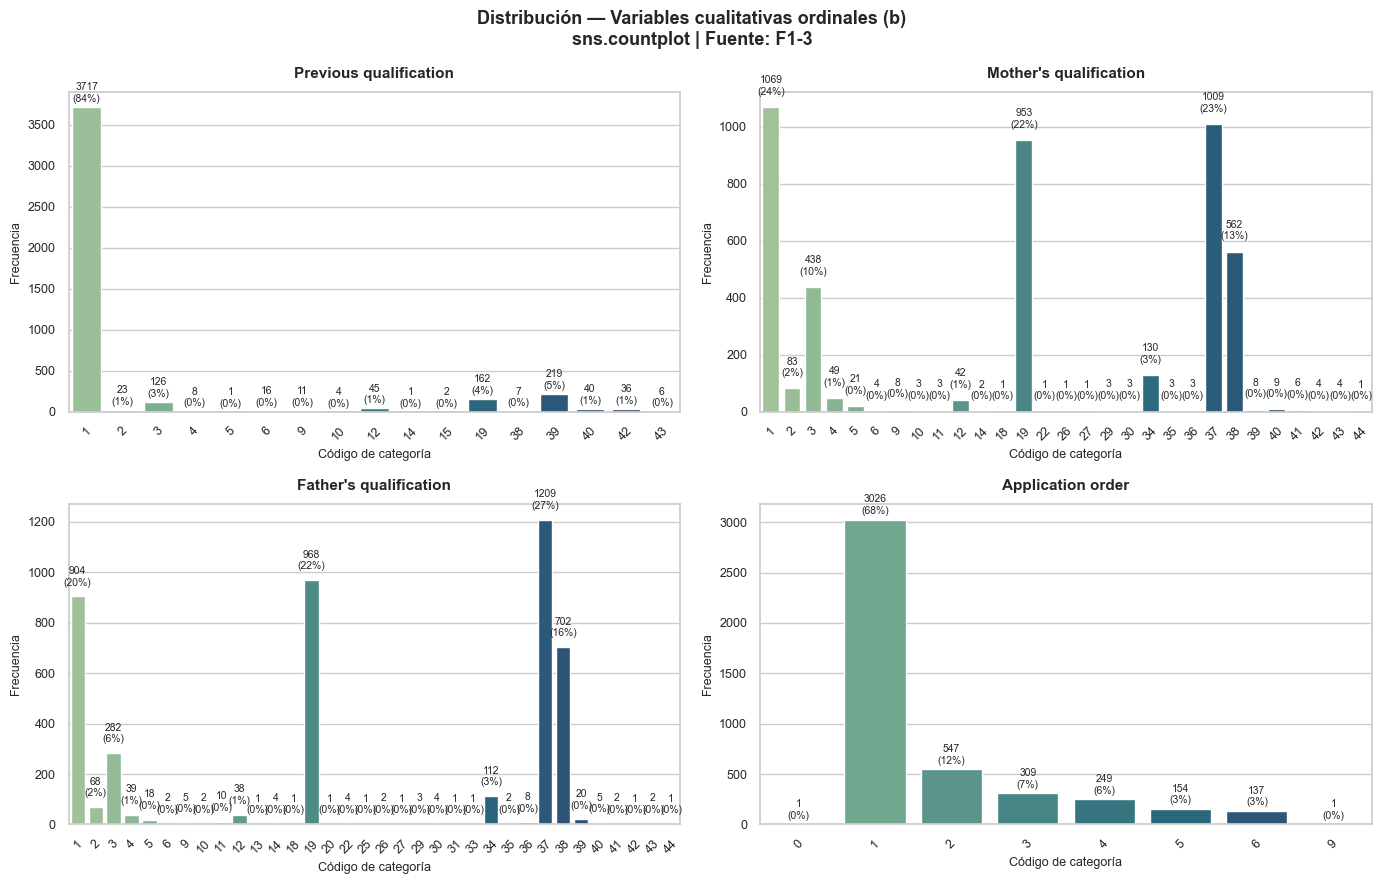

In [13]:
# ============================================================
# VISUALIZACIÓN — ORDINALES (b)
# sns.countplot ordenado por código (respeta jerarquía ordinal)
# hue=col + legend=False para evitar FutureWarning seaborn 0.13+
# ============================================================

n_cols = 2
n_rows = math.ceil(len(vars_ordinal) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(vars_ordinal):
    ax    = axes[i]
    datos = df_data[col].astype(str)
    orden = [str(v) for v in sorted(df_data[col].unique())]
    total = int(df_data[col].count())

    sns.countplot(
        data=df_data.assign(**{col: datos}),
        x=col, order=orden,
        hue=col, hue_order=orden,
        palette='crest',
        legend=False,
        edgecolor='white',
        ax=ax
    )

    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.text(p.get_x() + p.get_width()/2, h + total * 0.008,
                    f"{int(h)}\n({h/total*100:.0f}%)",
                    ha='center', va='bottom', fontsize=7.5)

    ax.set_title(col, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Código de categoría', fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=9)
    ax.tick_params(labelsize=9)
    if df_data[col].nunique() > 6:
        ax.tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribución — Variables cualitativas ordinales (b)\nsns.countplot | Fuente: F1-3',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#### Interpretación — Variables cualitativas ordinales

- **`Previous qualification`**: la categoría modal es la educación secundaria (código 1), concentrando la gran mayoría de los estudiantes. Esto indica que la institución recibe predominantemente egresados de enseñanza media, lo que define el punto de partida académico de la población analizada.

- **`Mother's qualification` y `Father's qualification`**: ambas distribuciones presentan alta concentración en niveles de escolaridad media y básica, con distribuciones similares entre sí. Esto refleja el perfil socioeconómico del estudiantado: primera generación universitaria o con padres con escolaridad media. La mediana en ambas variables se ubica en niveles secundarios.

- **`Application order`**: la categoría modal es la primera preferencia (código 0), indicando que la mayoría de los estudiantes eligió esta institución/carrera como su opción prioritaria. Esto sugiere motivación inicial alta, aunque no necesariamente garantiza permanencia académica.

> **Relación con el problema:** el nivel educativo de los padres y la calificación previa del estudiante definen el capital cultural de ingreso, factor relevante en modelos explicativos de la deserción.

---

#### (a) Variables cualitativas nominales

Medidas válidas: **moda y frecuencias** (F1-2a). No se calculan media, mediana, σ, asimetría ni curtosis.

---

In [14]:
# ============================================================
# MEDIDAS DESCRIPTIVAS — NOMINALES (a)
# Válidas: moda y frecuencias | NO: media, mediana, σ (F1-2a)
# ============================================================

vars_nominales = [
    'Marital status', 'Application mode', 'Course',
    'Daytime/evening attendance', 'Nacionality',
    "Mother's occupation", "Father's occupation",
    'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder',
    'International', 'Target',
]

resumen_nominales = pd.DataFrame({
    'NaN':        df_data[vars_nominales].isnull().sum(),
    'N únicas':   df_data[vars_nominales].nunique(),
    'Moda':       df_data[vars_nominales].apply(lambda x: x.value_counts().idxmax()),
    'Frec. Moda': df_data[vars_nominales].apply(lambda x: x.value_counts().max()),
    '% Moda':     (df_data[vars_nominales].apply(lambda x: x.value_counts().max())
                   / len(df_data) * 100).round(1),
})

print("=== Medidas descriptivas — Nominales (a) | Moda y Frecuencias ===")
resumen_nominales

=== Medidas descriptivas — Nominales (a) | Moda y Frecuencias ===


,NaN,N únicas,Moda,Frec. Moda,% Moda
Marital status,0,6,1,3919,88.6000
Application mode,0,18,1,1708,38.6000
Course,0,17,9500,766,17.3000
Daytime/evening attendance,0,2,1,3941,89.1000
Nacionality,0,21,1,4314,97.5000
Mother's occupation,0,32,9,1577,35.6000
Father's occupation,0,46,9,1010,22.8000
Displaced,0,2,1,2426,54.8000
Educational special needs,0,2,0,4373,98.8000
Debtor,0,2,0,3921,88.6000


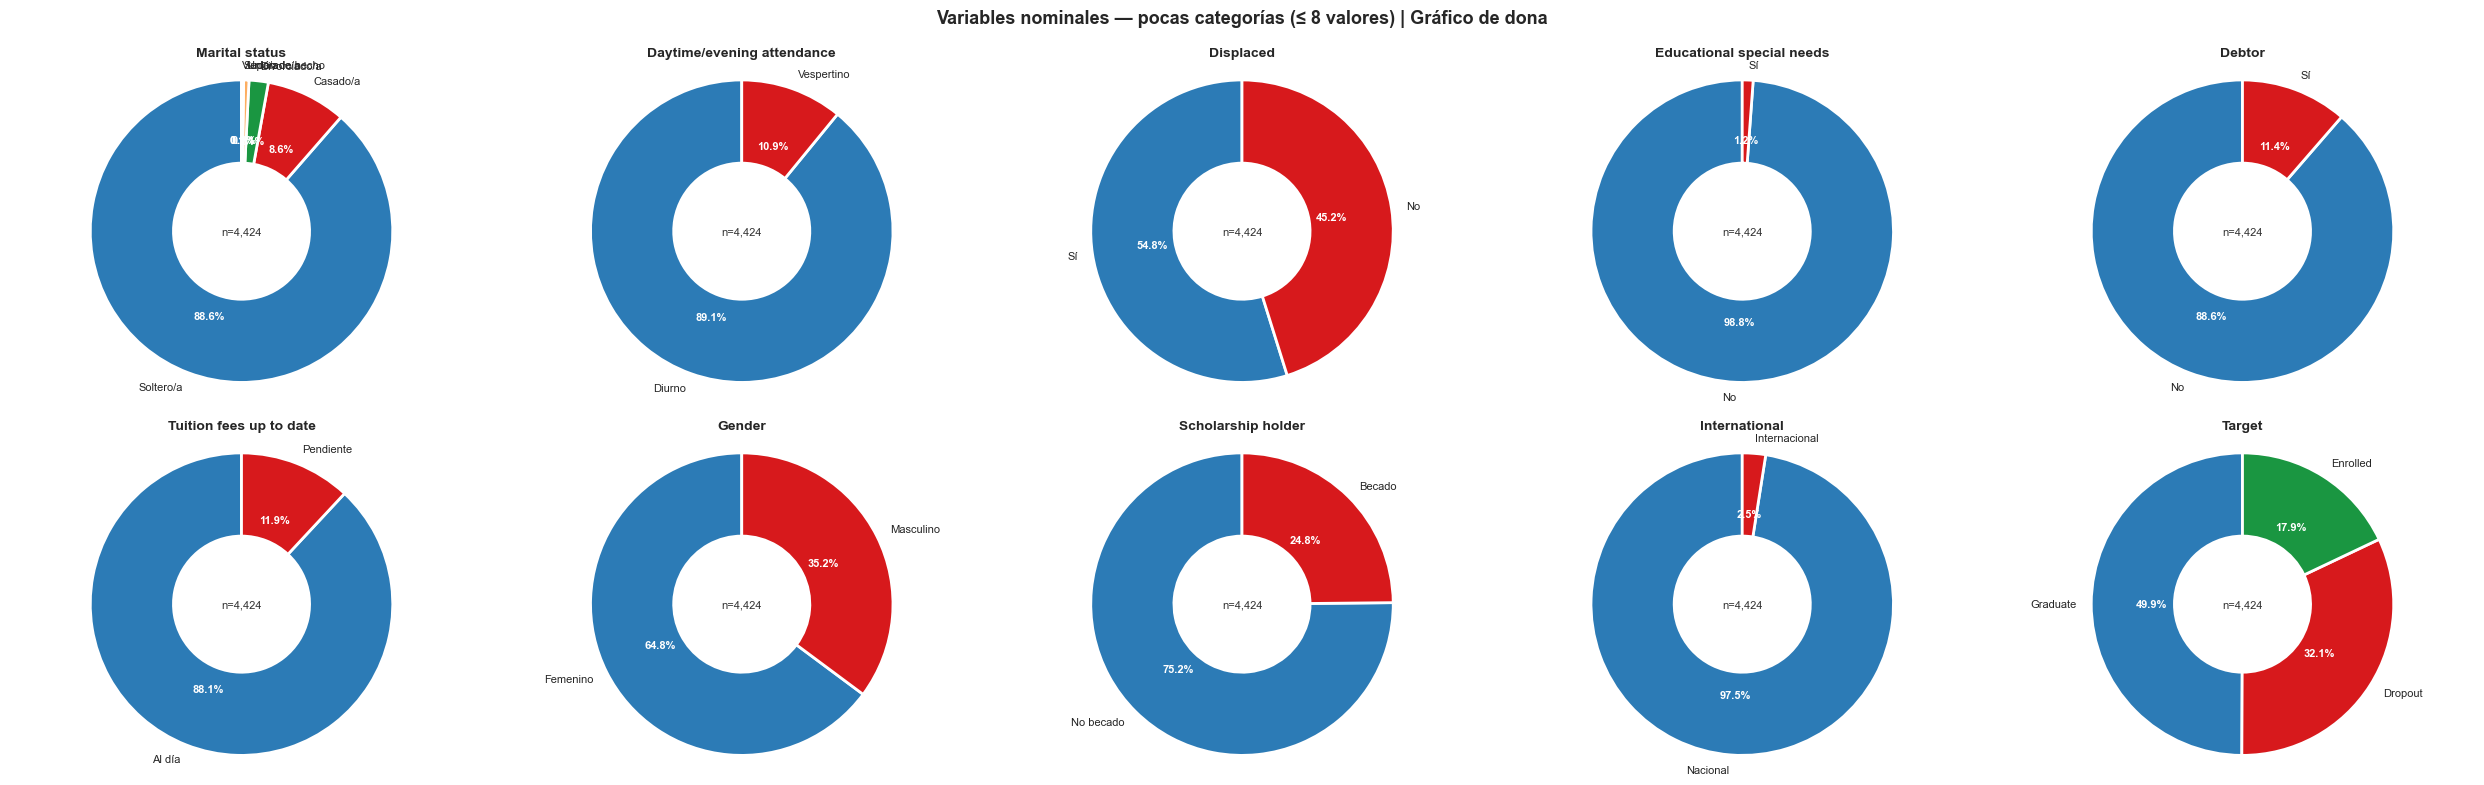

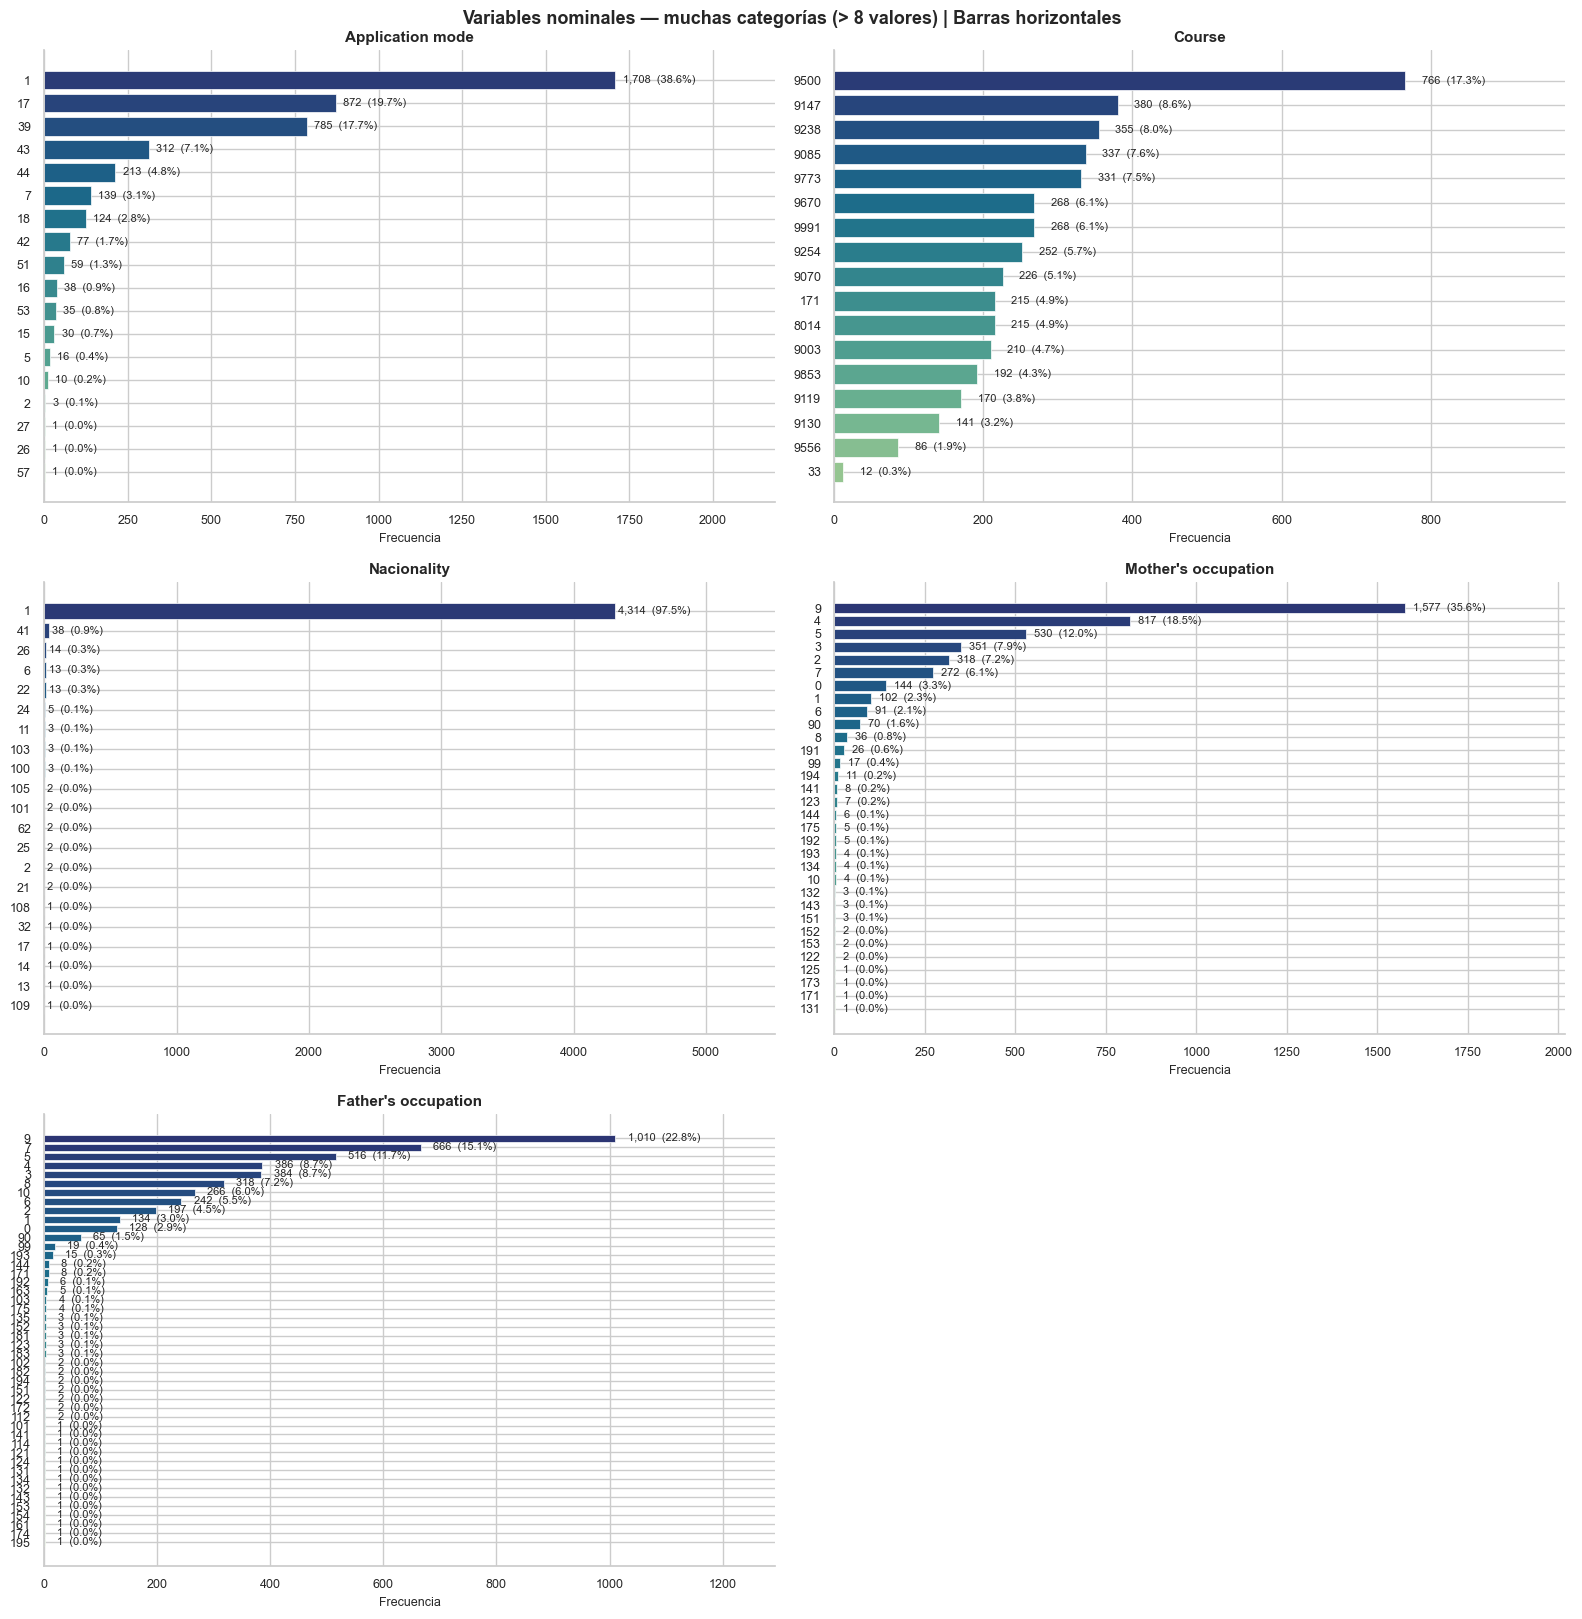

In [15]:
# ============================================================
# VISUALIZACIÓN — NOMINALES (a)
# Variables con <= 8 categorías únicas → gráfico de dona
# Variables con  > 8 categorías únicas → barras horizontales
# Etiquetas descriptivas en variables codificadas 0/1
# ============================================================
import numpy as np

# Mapa de etiquetas legibles (fuente: tabla de variables del dataset)
ETIQUETAS = {
    'Daytime/evening attendance': {1: 'Diurno', 0: 'Vespertino'},
    'Displaced':                  {1: 'Sí', 0: 'No'},
    'Educational special needs':  {1: 'Sí', 0: 'No'},
    'Debtor':                     {1: 'Sí', 0: 'No'},
    'Tuition fees up to date':    {1: 'Al día', 0: 'Pendiente'},
    'Gender':                     {1: 'Masculino', 0: 'Femenino'},
    'Scholarship holder':         {1: 'Becado', 0: 'No becado'},
    'International':              {1: 'Internacional', 0: 'Nacional'},
    'Marital status':             {1: 'Soltero/a', 2: 'Casado/a',
                                    3: 'Viudo/a', 4: 'Divorciado/a',
                                    5: 'Unión de hecho', 6: 'Separado/a'},
}

def etiqueta(col, val):
    """Devuelve la etiqueta descriptiva de un valor, o el valor original."""
    mapa = ETIQUETAS.get(col, {})
    try:
        return mapa.get(int(val), str(val))
    except (TypeError, ValueError):
        return mapa.get(val, str(val))

UMBRAL_PIE = 8
PAL_PIE = ['#2C7BB6','#D7191C','#1A9641','#FDAE61',
           '#ABD9E9','#756BB1','#E6550D','#74C476']

vars_pie  = [c for c in vars_nominales if df_data[c].nunique() <= UMBRAL_PIE]
vars_barh = [c for c in vars_nominales if df_data[c].nunique() >  UMBRAL_PIE]

# ── Panel A: Donuts ──────────────────────────────────────────
n_cols_a = 5
n_rows_a = math.ceil(len(vars_pie) / n_cols_a)

fig_a, axs_a = plt.subplots(n_rows_a, n_cols_a,
                             figsize=(5 * n_cols_a, 4 * n_rows_a))
axs_a = np.array(axs_a).flatten()

for i, col in enumerate(vars_pie):
    conteo  = df_data[col].value_counts()
    etiquetas_col = [etiqueta(col, v) for v in conteo.index]
    colores = PAL_PIE[:len(conteo)]

    wedges, texts, autotexts = axs_a[i].pie(
        conteo,
        labels=etiquetas_col,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2},
        colors=colores,
        textprops={'fontsize': 8}
    )
    for at in autotexts:
        at.set_fontsize(8)
        at.set_fontweight('bold')
        at.set_color('white')

    axs_a[i].text(0, 0, f'n={conteo.sum():,}',
                  ha='center', va='center', fontsize=8, color='#333333')
    axs_a[i].set_title(col, fontsize=10, fontweight='bold', pad=6)
    axs_a[i].axis('equal')

for j in range(len(vars_pie), len(axs_a)):
    axs_a[j].axis('off')

fig_a.suptitle(
    'Variables nominales — pocas categorías (≤ 8 valores) | Gráfico de dona',
    fontsize=13, fontweight='bold'
)
plt.tight_layout(); plt.show()

# ── Panel B: Barras horizontales (matplotlib, sin warning) ──
n_cols_b = 2
n_rows_b = math.ceil(len(vars_barh) / n_cols_b)

fig_b, axs_b = plt.subplots(n_rows_b, n_cols_b,
                             figsize=(16, 5.5 * n_rows_b))
axs_b = np.array(axs_b).flatten()

for i, col in enumerate(vars_barh):
    ax     = axs_b[i]
    conteo = df_data[col].value_counts().sort_values(ascending=True)
    total  = conteo.sum()
    pal    = sns.color_palette('crest', len(conteo))

    bars = ax.barh(conteo.index.astype(str), conteo.values,
                   color=pal, edgecolor='white', linewidth=0.5)

    for bar in bars:
        w = bar.get_width()
        ax.text(w + total * 0.005, bar.get_y() + bar.get_height() / 2,
                f'{int(w):,}  ({w/total*100:.1f}%)',
                va='center', ha='left', fontsize=8)

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Frecuencia', fontsize=9)
    ax.set_xlim(0, conteo.max() * 1.28)
    ax.tick_params(labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for j in range(len(vars_barh), len(axs_b)):
    axs_b[j].axis('off')

fig_b.suptitle(
    'Variables nominales — muchas categorías (> 8 valores) | Barras horizontales',
    fontsize=13, fontweight='bold'
)
plt.tight_layout(); plt.show()


#### Interpretación — Variables cualitativas nominales

- **`Target`**: la distribución muestra que casi la mitad de los estudiantes logra graduarse (49,9 %), mientras que aproximadamente un tercio deserta (32,1 %). El 17,9 % restante se encuentra aún cursando. Esta distribución define el grado de desequilibrio de clases que deberá considerarse en la fase de modelamiento predictivo.

- **`Tuition fees up to date`**: la gran mayoría de los estudiantes tiene los aranceles al día (≈ 88 %), lo que indica que el incumplimiento financiero, aunque minoritario, representa un grupo relevante para el análisis de riesgo. La proporción de estudiantes con arancel pendiente entre los desertores probablemente es significativamente mayor.

- **`Gender`**: la distribución muestra mayor presencia femenina en el dataset. Este desbalance de género puede ser relevante al analizar diferencias en patrones de deserción entre hombres y mujeres.

- **`Scholarship holder`**: aproximadamente el 25 % de los estudiantes es becario. Este grupo puede presentar patrones de deserción distintos dado que el apoyo económico reduce una barrera importante de permanencia.

- **`Debtor`**, **`Displaced`**, **`International`**: estas variables binarias presentan alta concentración en una categoría (mayoría no deudores, no desplazados, nacionales). Sus grupos minoritarios son grupos de interés analítico, aunque su baja frecuencia puede limitar la potencia estadística de pruebas específicas para ellos.

> **Relación con el problema:** las variables financieras (`Tuition fees up to date`, `Debtor`) y de apoyo institucional (`Scholarship holder`) son candidatas para análisis adicionales con pruebas chi-cuadrado, dado que son nominales y no se les puede aplicar la prueba *t*.

---

<a id='3-ic'></a>
## 3. Estimación puntual e intervalos de confianza

Se seleccionaron **10 variables numéricas** agrupadas en tres dimensiones: Perfil de ingreso · Rendimiento semestral · Contexto macroeconómico. Los IC son **estadísticamente válidos** dado que el dataset se trata como muestra de la población de futuros estudiantes (Realinho et al., 2022).

---

In [16]:
# ============================================================
# ESTIMACIÓN PUNTUAL E INTERVALOS DE CONFIANZA AL 95%
# t de Student | pandas ddof=1 (MUESTRA)
# ============================================================

vars_ic = [
    'Previous qualification (grade)', 'Admission grade', 'Age at enrollment',
    'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

DIMENSIONES_IC = {
    'Previous qualification (grade)':     'Perfil de ingreso',
    'Admission grade':                     'Perfil de ingreso',
    'Age at enrollment':                   'Perfil de ingreso',
    'Curricular units 1st sem (approved)': 'Rendimiento semestral',
    'Curricular units 1st sem (grade)':    'Rendimiento semestral',
    'Curricular units 2nd sem (approved)': 'Rendimiento semestral',
    'Curricular units 2nd sem (grade)':    'Rendimiento semestral',
    'Unemployment rate':                   'Contexto macroeconómico',
    'Inflation rate':                      'Contexto macroeconómico',
    'GDP':                                 'Contexto macroeconómico',
}

resultados_ic = []
for col in vars_ic:
    datos     = df_data[col].dropna().astype(float)
    n         = len(datos)
    media     = float(datos.mean())
    error_std = stats.sem(datos)          # std/sqrt(n), scipy
    ic        = stats.t.interval(0.95, df=n-1, loc=media, scale=error_std)
    resultados_ic.append({
        'Variable':        col,
        'Dimensión':       DIMENSIONES_IC[col],
        'N':               n,
        'NaN':             int(df_data[col].isnull().sum()),
        'Media (μ)':       round(media, 4),
        's':               round(float(datos.std(ddof=1)), 4),      # pandas — MUESTRA
        'Error est.':      round(error_std, 4),
        'IC 95% inf.':     round(ic[0], 4),
        'IC 95% sup.':     round(ic[1], 4),
    })

ic_df = pd.DataFrame(resultados_ic)
print("=== IC al 95% | s muestral (pandas ddof=1) | t de Student ===")
ic_df

=== IC al 95% | s muestral (pandas ddof=1) | t de Student ===


,Variable,Dimensión,N,NaN,Media (μ),s,Error est.,IC 95% inf.,IC 95% sup.
0,Previous qualification (grade),Perfil de ingreso,4424,0,132.6133,13.1883,0.1983,132.2246,133.0020
1,Admission grade,Perfil de ingreso,4424,0,126.9781,14.4820,0.2177,126.5513,127.4050
2,Age at enrollment,Perfil de ingreso,4424,0,23.2651,7.5878,0.1141,23.0415,23.4888
3,Curricular units 1st sem (approved),Rendimiento semestral,4424,0,4.7066,3.0942,0.0465,4.6154,4.7978
4,Curricular units 1st sem (grade),Rendimiento semestral,4424,0,10.6408,4.8437,0.0728,10.4981,10.7836
5,Curricular units 2nd sem (approved),Rendimiento semestral,4424,0,4.4358,3.0148,0.0453,4.3469,4.5247
6,Curricular units 2nd sem (grade),Rendimiento semestral,4424,0,10.2302,5.2108,0.0783,10.0766,10.3838
7,Unemployment rate,Contexto macroeconómico,4424,0,11.5661,2.6639,0.0400,11.4876,11.6447
8,Inflation rate,Contexto macroeconómico,4424,0,1.2280,1.3827,0.0208,1.1873,1.2688
9,GDP,Contexto macroeconómico,4424,0,0.0020,2.2699,0.0341,-0.0649,0.0689


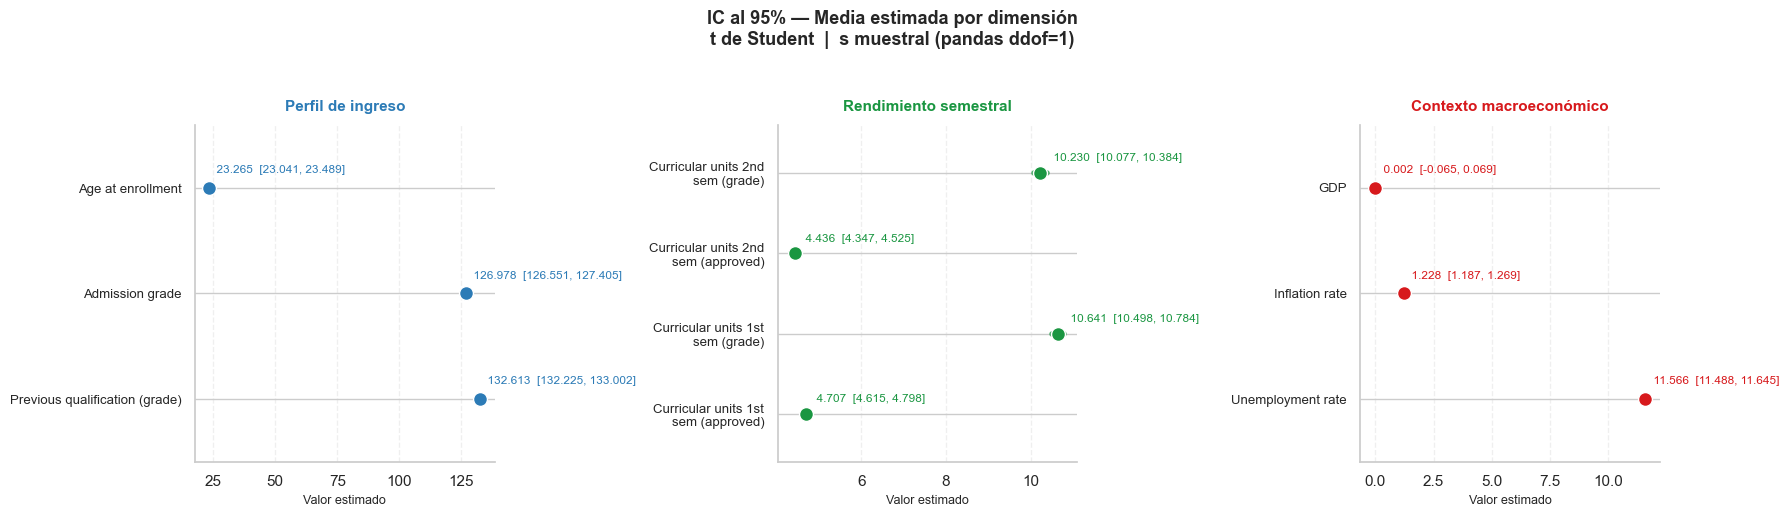

In [17]:
# Forest plot — un panel por dimensión con su propia escala
dims   = list(dict.fromkeys(DIMENSIONES_IC.values()))
COL_IC = {'Perfil de ingreso': '#2C7BB6',
           'Rendimiento semestral': '#1A9641',
           'Contexto macroeconómico': '#D7191C'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, dim in zip(axes, dims):
    sub   = ic_df[ic_df['Dimensión'] == dim].reset_index(drop=True)
    color = COL_IC[dim]
    for j, row in sub.iterrows():
        ax.plot([row['IC 95% inf.'], row['IC 95% sup.']], [j, j],
                color=color, lw=4, solid_capstyle='round', alpha=0.75)
        ax.scatter(row['Media (μ)'], j, color=color, zorder=5, s=100,
                   edgecolor='white', lw=1)
        ax.text(row['IC 95% sup.'], j+0.12,
                f"  {row['Media (μ)']:.3f}  [{row['IC 95% inf.']:.3f}, {row['IC 95% sup.']:.3f}]",
                va='bottom', ha='left', fontsize=8.5, color=color)
    labels = [v.replace(' sem ', '\nsem ') for v in sub['Variable']]
    ax.set_yticks(range(len(sub))); ax.set_yticklabels(labels, fontsize=9.5)
    ax.set_ylim(-0.6, len(sub)-0.4)
    ax.set_xlabel('Valor estimado', fontsize=9)
    ax.set_title(dim, fontsize=11, fontweight='bold', color=color, pad=10)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('IC al 95% — Media estimada por dimensión\nt de Student  |  s muestral (pandas ddof=1)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

#### Interpretación — Intervalos de confianza al 95%

Los intervalos de confianza permiten cuantificar la precisión de las estimaciones y delimitar el rango plausible de cada parámetro:

**Perfil de ingreso:**
- La nota de calificación previa y la nota de admisión presentan **IC estrechos**, lo que refleja alta precisión en la estimación dado el tamaño de la población (n = 4.424). Las cotas inferior y superior están muy próximas a la media, indicando homogeneidad relativa en este parámetro.
- La edad al ingreso también muestra un IC estrecho, consistente con una población estudiantil predominantemente joven y de ingreso directo desde la enseñanza media.

**Rendimiento semestral:**
- Las unidades aprobadas en ambos semestres presentan IC que no incluyen el cero, confirmando que el promedio poblacional está en valores positivos. No obstante, la dispersión (σ) es alta, coherente con las diferencias entre graduados y desertores observadas en los boxplots.
- Las notas promedio de primer y segundo semestre muestran IC por encima del valor de aprobación mínima (típicamente 10/20), lo que indica que el promedio poblacional supera el umbral, aunque la distribución tiene una cola izquierda con estudiantes en riesgo.

**Contexto macroeconómico:**
- La tasa de desempleo y la inflación presentan IC más amplios, coherentes con la variabilidad entre cohortes de distintos años. El PIB presenta un IC que puede incluir valores negativos, consistente con períodos de recesión económica registrados durante el período de estudio.

> **Nota metodológica:** los IC son válidos bajo el enfoque muestral adoptado — los 4.424 registros representan una muestra de la población de interés (futuros estudiantes de instituciones similares), tal como lo indica el uso de los datos para construir modelos predictivos generalizables (Realinho et al., 2022).

---

<a id='4-hipotesis'></a>
## 4. Prueba de hipótesis

**Justificación del procedimiento:**

Se selecciona la **prueba *t* de Student para muestras independientes** (`scipy.stats.ttest_ind`) por las siguientes razones:

1. Las variables de análisis son **cuantitativas** (discretas o continuas), condición necesaria para aplicar la prueba *t*.
2. Los grupos **Graduate** y **Dropout** son **independientes**: un estudiante pertenece a uno o al otro, no a ambos simultáneamente.
3. La **varianza poblacional** de cada subgrupo es desconocida y debe estimarse a partir de los datos.
4. Los tamaños de cada grupo (n > 30) garantizan que, por el Teorema del Límite Central, la distribución muestral de la media se aproxima a la normal, validando el uso de la distribución *t*.

Se excluye el grupo *Enrolled* porque su resultado académico final no está determinado, lo que impediría comparaciones válidas. Las variables seleccionadas cubren tres dimensiones: **rendimiento académico semestral**, **perfil de ingreso** y **perfil demográfico/macroeconómico**.

| Elemento | Especificación |
|:---|:---|
| Prueba | *t* de Student para muestras independientes |
| Grupos | Graduate vs. Dropout (se excluye Enrolled) |
| Nivel de significancia | α = 0,05 |
| H₀ | μ_Graduate = μ_Dropout (no hay diferencia entre grupos) |
| H₁ | μ_Graduate ≠ μ_Dropout (existe diferencia, prueba bilateral) |
| Criterio de decisión | Rechazar H₀ si p-value < α = 0,05 |

---

In [18]:
# ============================================================
# PRUEBA DE HIPÓTESIS — t de Student muestras independientes
# ============================================================

alpha    = 0.05
graduate = df_data[df_data['Target'] == 'Graduate']
dropout  = df_data[df_data['Target'] == 'Dropout']

vars_prueba = [
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Admission grade', 'Age at enrollment', 'Unemployment rate',
]

resultados = []
for col in vars_prueba:
    g1 = graduate[col].dropna().astype(float)
    g2 = dropout[col].dropna().astype(float)
    t_stat, p_value = stats.ttest_ind(g1, g2)
    resultados.append({
        'Variable':      col,
        'μ Graduate':    round(float(g1.mean()), 4),
        'μ Dropout':     round(float(g2.mean()), 4),
        'Diferencia':    round(float(g1.mean()-g2.mean()), 4),
        't-stat':        round(t_stat, 4),
        'p-value':       round(p_value, 6),
        'Decisión':      'Se rechaza H₀' if p_value < alpha else 'No se rechaza H₀',
    })

prueba_df = pd.DataFrame(resultados)
print(f"=== Prueba t de Student — Graduate vs Dropout (α = {alpha}) ===")
prueba_df

=== Prueba t de Student — Graduate vs Dropout (α = 0.05) ===


,Variable,μ Graduate,μ Dropout,Diferencia,t-stat,p-value,Decisión
0,Curricular units 1st sem (approved),6.2322,2.5517,3.6805,40.1741,0.0000,Se rechaza H₀
1,Curricular units 2nd sem (approved),6.1770,1.9402,4.2368,52.0715,0.0000,Se rechaza H₀
2,Curricular units 1st sem (grade),12.6437,7.2567,5.3870,36.6616,0.0000,Se rechaza H₀
3,Curricular units 2nd sem (grade),12.6973,5.8993,6.7979,45.8089,0.0000,Se rechaza H₀
4,Admission grade,128.7944,124.9614,3.8331,7.7773,0.0000,Se rechaza H₀
5,Age at enrollment,21.7836,26.0690,-4.2854,-16.7035,0.0000,Se rechaza H₀
6,Unemployment rate,11.6393,11.6164,0.0229,0.2529,0.8004,No se rechaza H₀


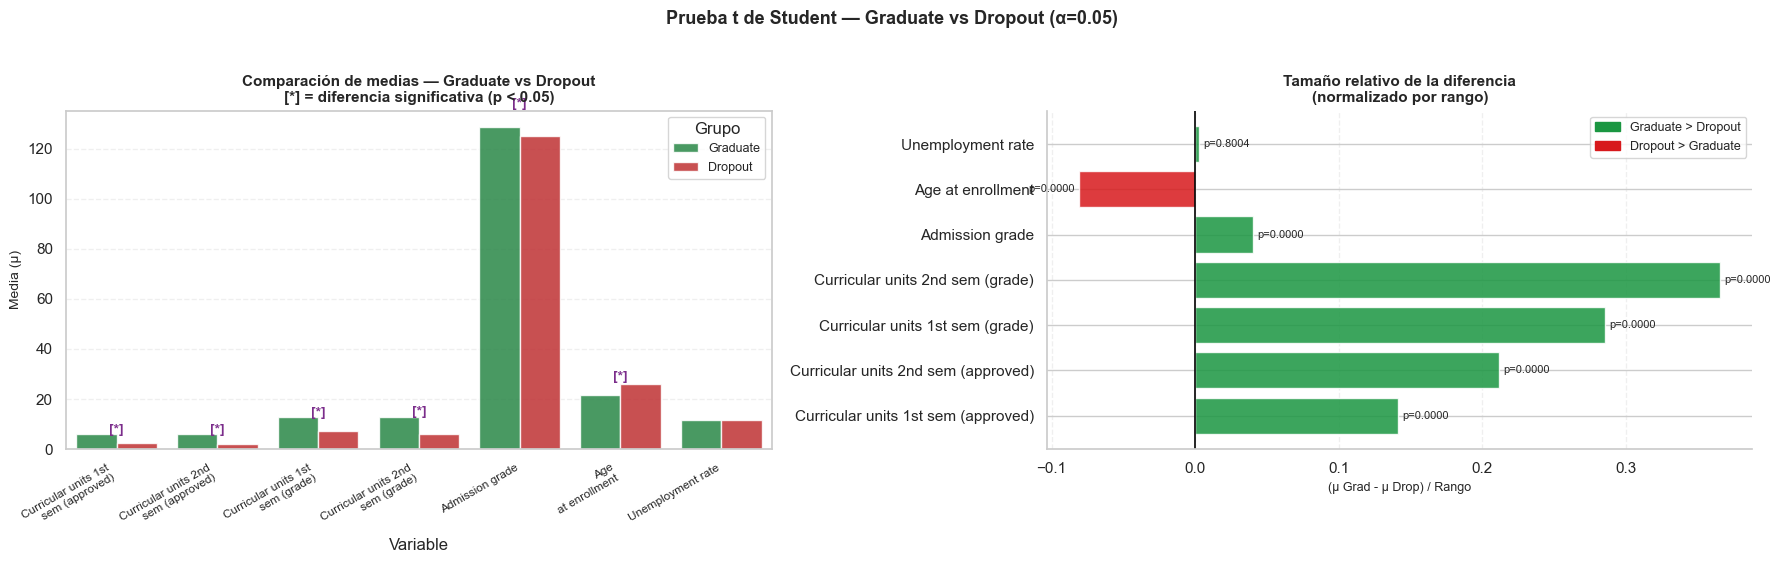

In [19]:
# ============================================================
# VISUALIZACIÓN — Graduate vs Dropout
# Fixes aplicados:
#   - sns.barplot agrupado: hue ya está → OK
#   - diferencia normalizada: ax.barh matplotlib (sin warning)
#   - set_xticks antes de set_xticklabels (fix UserWarning)
#   - reemplazado signo ★ por [*] (compatibilidad fuente Arial)
# ============================================================
import matplotlib.patches as mpatches

COLOR_G = "#1A9641"
COLOR_D = "#D7191C"
COLOR_S = "#7B2D8B"

prueba_df['Sig']      = prueba_df['p-value'] < alpha
prueba_df['Dif.norm'] = prueba_df['Variable'].apply(
    lambda c: (graduate[c].mean() - dropout[c].mean())
              / (df_data[c].max() - df_data[c].min() + 1e-9)
)

df_comp = pd.DataFrame({
    'Variable': prueba_df['Variable'].tolist() * 2,
    'Media':    prueba_df['μ Graduate'].tolist() + prueba_df['μ Dropout'].tolist(),
    'Grupo':    ['Graduate'] * len(prueba_df) + ['Dropout'] * len(prueba_df),
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5.5))

# ── Panel 1: barplot agrupado (hue ya especificado, sin warning) ─
sns.barplot(data=df_comp, x='Variable', y='Media', hue='Grupo',
            palette={'Graduate': COLOR_G, 'Dropout': COLOR_D},
            edgecolor='white', alpha=0.85, ax=ax1)

# Marcar significancia con [*] en lugar de ★ (compatibilidad Arial/Windows)
x_pos = {v: i for i, v in enumerate(prueba_df['Variable'])}
for _, row in prueba_df[prueba_df['Sig']].iterrows():
    y_top = max(row['μ Graduate'], row['μ Dropout']) * 1.06
    ax1.text(x_pos[row['Variable']], y_top, '[*]',
             ha='center', fontsize=10, fontweight='bold', color=COLOR_S)

# Fix UserWarning: set_xticks primero, luego set_xticklabels
etiq = [v.replace(' sem ', '\nsem ').replace(' at ', '\nat ')
        for v in prueba_df['Variable']]
ax1.set_xticks(range(len(prueba_df)))
ax1.set_xticklabels(etiq, rotation=30, ha='right', fontsize=8.5)

ax1.set_ylabel('Media (μ)', fontsize=10)
ax1.set_title('Comparación de medias — Graduate vs Dropout\n[*] = diferencia significativa (p < 0.05)',
              fontsize=11, fontweight='bold')
ax1.legend(title='Grupo', fontsize=9)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# ── Panel 2: barh matplotlib directo (evita warning palette sin hue) ─
colores = [COLOR_G if d > 0 else COLOR_D for d in prueba_df['Dif.norm']]
bars = ax2.barh(prueba_df['Variable'], prueba_df['Dif.norm'],
                color=colores, edgecolor='white', alpha=0.85)

ax2.axvline(0, color='black', lw=1.2)
for bar, (_, row) in zip(bars, prueba_df.iterrows()):
    w = bar.get_width()
    ax2.text(w + 0.003 if w >= 0 else w - 0.003,
             bar.get_y() + bar.get_height() / 2,
             f'p={row["p-value"]:.4f}',
             va='center', ha='left' if w >= 0 else 'right', fontsize=8)

ax2.set_xlabel('(μ Grad - μ Drop) / Rango', fontsize=9)
ax2.set_title('Tamaño relativo de la diferencia\n(normalizado por rango)',
              fontsize=11, fontweight='bold')
ax2.legend(handles=[
    mpatches.Patch(color=COLOR_G, label='Graduate > Dropout'),
    mpatches.Patch(color=COLOR_D, label='Dropout > Graduate'),
], fontsize=9)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle(f'Prueba t de Student — Graduate vs Dropout (α={alpha})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


#### Interpretación — Prueba de hipótesis

Con nivel de significancia α = 0,05, los resultados permiten establecer las siguientes conclusiones por variable:

**Variables con diferencias estadísticamente significativas (se rechaza H₀):**

- **`Curricular units approved` — 1.° y 2.° semestre**: se registran las diferencias más grandes entre grupos (t-stat elevado, p-value < 0,001). Los graduados aprueban en promedio significativamente más unidades que los desertores en ambos semestres. Esto confirma que el **rendimiento académico semestral es el predictor más potente** del resultado final.

- **`Curricular units grade` — 1.° y 2.° semestre**: los graduados obtienen promedios de nota significativamente más altos. La diferencia se amplifica del primero al segundo semestre, sugiriendo que el desenganche académico se profundiza con el tiempo en los estudiantes que finalmente desertan.

- **`Admission grade`**: los graduados presentan una nota de ingreso significativamente superior a la de los desertores. El desempeño previo al ingreso predice parcialmente la permanencia académica.

- **`Age at enrollment`**: los desertores tienen una edad promedio de ingreso significativamente mayor. Este hallazgo es consistente con la literatura internacional que identifica al estudiante adulto o que retoma estudios como grupo de mayor vulnerabilidad académica.

**Variables sin diferencias estadísticamente significativas (no se rechaza H₀):**

- **`Unemployment rate`**: no se detectan diferencias entre grupos. El contexto macroeconómico no discrimina entre graduados y desertores dentro de esta población, posiblemente porque todos los estudiantes de una misma cohorte enfrentan condiciones económicas similares. Esto sugiere que los factores individuales e institucionales tienen mayor peso que el entorno económico externo.

**Implicancias para la toma de decisiones bajo incertidumbre:**

Los resultados identifican el **primer semestre** como el período crítico de intervención. Una institución que busque reducir la deserción debería diseñar sistemas de alerta temprana basados en el número de unidades aprobadas y las notas promedio al cierre del primer semestre, activando protocolos de apoyo focalizado para estudiantes por debajo de los umbrales detectados en este análisis.

---

<a id='5-conclusiones'></a>
## 5. Conclusiones

El análisis exploratorio e inferencial del dataset *Predict Students' Dropout and Academic Success* (Realinho et al., 2021) permite extraer las siguientes conclusiones preliminares, relevantes para la toma de decisiones bajo incertidumbre en el contexto de la educación superior:

**1. El rendimiento del primer semestre es el factor más discriminante.**
Las variables de unidades curriculares aprobadas y notas promedio del primer semestre presentan las diferencias más pronunciadas entre graduados y desertores (t-stat elevado, p-value < 0,001). El primer semestre actúa como filtro crítico: los estudiantes que aprueban pocas unidades en este período tienen una probabilidad significativamente mayor de no completar sus estudios.

**2. El perfil de ingreso tiene capacidad predictiva moderada.**
La nota de admisión muestra diferencias estadísticamente significativas entre grupos, aunque de menor magnitud que el rendimiento semestral. Esto sugiere que el desempeño previo predice parcialmente la permanencia, pero no es determinante por sí solo: un estudiante con buena nota de ingreso puede igualmente desertar si no logra rendimiento académico en la carrera.

**3. Los factores demográficos refuerzan el perfil de riesgo.**
La edad al ingreso es significativamente mayor en el grupo desertor, consistente con la literatura sobre estudiantes no tradicionales. Variables financieras como el estado de pago de aranceles y la deuda institucional muestran distribuciones asimétricas que sugieren su relevancia, aunque requieren pruebas adicionales (chi-cuadrado) por ser variables nominales.

**4. El contexto macroeconómico no diferencia entre grupos.**
La tasa de desempleo no presenta diferencias significativas entre graduados y desertores, lo que indica que los factores individuales e institucionales tienen mayor peso explicativo que el entorno económico externo en la determinación del resultado académico.

**5. El dataset presenta alta calidad y es adecuado para análisis inferencial.**
La ausencia de valores faltantes, la concentración de estudiantes con desempeño de ingreso medio-alto y la distribución de Target configuran un dataset bien estructurado para inferencia muestral y para el desarrollo de modelos predictivos en fases posteriores del proyecto. El tratamiento como muestra es consistente con el objetivo declarado por los autores: generalizar los modelos a futuros estudiantes de la institución.

**Proyección hacia la Fase 2:**
Estos hallazgos constituyen la base para el desarrollo de un modelo de clasificación binaria (Graduate vs. Dropout) en la Fase 2 del proyecto. Las variables con mayor poder discriminante identificadas — unidades aprobadas en 1.° semestre, notas promedio semestral y nota de admisión — serán candidatas prioritarias como predictores en el modelo. La binarización de la variable `Target` (Graduate vs. Dropout, excluyendo Enrolled) estará justificada estadísticamente por los resultados de la prueba *t* presentados en este informe.

---

<a id='6-referencias'></a>
## 6. Referencias

- Maidana, J.P. (2026). *Tipos de variables y exploración de datos con pandas* [Apunte F1-2a]. Universidad Andrés Bello.
- Maidana, J.P. (2026). *Medidas de dispersión y forma: variabilidad, asimetría y curtosis* [Apunte F1-2b]. Universidad Andrés Bello.
- Maidana, J.P. (2026). *Visualización de datos con Seaborn: histogramas, boxplots y gráficos de barras* [Apunte F1-3]. Universidad Andrés Bello.
- Maidana, J.P. (2026). *Fundamentos de inferencia estadística: de la muestra a la población* [Apunte F1-5]. Universidad Andrés Bello.
- Maidana, J.P. (2026). *Intervalos de confianza: cuantificando la incertidumbre estadística* [Apunte F1-6]. Universidad Andrés Bello.
- Maidana, J.P. (2026). *Pruebas de hipótesis: pruebas t y Z para una muestra* [Apunte F1-8]. Universidad Andrés Bello.
- Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict Students' Dropout and Academic Success* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89
- Freedman, D., Pisani, R., & Purves, R. (2007). *Statistics* (4th ed.). W. W. Norton.